## **Выгрузка исходных данных**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем данные
df = pd.read_csv('smolensk_data.csv', sep=';')

# Очищаем названия колонок
df.columns = df.columns.str.strip()
df

,period_start,year,quarter,period_index,Исполнение бюджета. %,Благоустроенные дворы. ед.,Удовлетворенность городской средой. %,Исполнение бюджета. %,Отремонтированные дороги. км,Дороги в нормативном состоянии. %,...,Пассажиропоток. тыс. поездок.1,Рейсы по расписанию. %.1,Средняя скорость на магистралях. км/ч.1,ДТП на 10 тыс. жителей.1,Срок устранения дефектов. суток.1,Регулируемые переходы. ед..1,Исполнение бюджета. %.4,Отремонтированные дороги. км.2,Дороги в нормативном состоянии. %.2,Срок устранения дефектов. суток.2
0,2006-01-01,2006,1,1,69.0,17.0,35.3,70.8,19.06,43.6,...,33.0,58.0,25.6,26.7,6.6,16.0,66.3,1.47,59.9,37.9
1,2006-04-01,2006,2,2,75.8,24.0,33.6,72.8,40.52,42.6,...,42.9,57.2,23.5,23.9,6.3,23.0,75.1,3.35,62.0,38.0
2,2006-07-01,2006,3,3,76.6,31.0,36.3,78.3,47.54,42.4,...,48.2,57.9,27.2,21.8,6.2,28.0,79.0,3.89,60.8,36.1
3,2006-10-01,2006,4,4,86.0,33.0,35.2,85.3,36.27,41.3,...,38.4,58.5,27.5,21.9,6.2,29.0,84.1,2.97,61.4,36.4
4,2007-01-01,2007,1,5,71.2,18.0,33.1,69.7,17.89,40.9,...,33.0,58.4,27.4,25.2,6.1,16.0,72.4,1.51,58.7,39.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2024-10-01,2024,4,76,94.6,67.0,49.6,94.4,55.11,50.0,...,83.5,69.4,29.4,10.0,3.4,57.0,93.4,3.60,63.4,18.6
76,2025-01-01,2025,1,77,79.9,36.0,49.7,79.1,26.45,50.1,...,73.9,71.0,29.3,10.3,3.2,31.0,78.0,1.76,64.5,18.6
77,2025-04-01,2025,2,78,85.3,49.0,48.8,87.4,57.95,50.4,...,100.4,70.3,30.8,9.5,3.2,46.0,86.8,3.85,64.5,19.1
78,2025-07-01,2025,3,79,91.9,58.0,49.6,87.5,71.69,52.3,...,113.8,69.3,28.1,8.5,3.3,55.0,89.1,4.70,63.6,17.8


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 35 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   period_start                                  80 non-null     object 
 1   year                                          80 non-null     int64  
 2   quarter                                       80 non-null     int64  
 3   period_index                                  80 non-null     int64  
 4   Исполнение бюджета. %                         80 non-null     float64
 5   Благоустроенные дворы. ед.                    80 non-null     float64
 6   Удовлетворенность городской средой. %         80 non-null     float64
 7   Исполнение бюджета. %                         80 non-null     float64
 8   Отремонтированные дороги. км                  80 non-null     float64
 9   Дороги в нормативном состоянии. %             80 non-null     float

## **Разведочный анализ**

In [ ]:
# График c усами
def get_boxplot(d, title):
  sns.set_style("darkgrid")
  sns.set_palette("viridis")

  plt.figure(figsize=(15, 10))
  ax = sns.boxplot(data=d, linewidth=2)

  ax.set_title(f'Распределение признаков: {title}',
             fontsize=12, fontweight='bold', pad=15)
  ax.set_xlabel('Признаки', fontsize=10, fontweight='bold')
  ax.set_ylabel('Значения', fontsize=10, fontweight='bold')
  ax.tick_params(labelsize=11)
  plt.xticks(rotation=45, ha='right')

  ax.grid(True, alpha=0.2)

  plt.tight_layout()


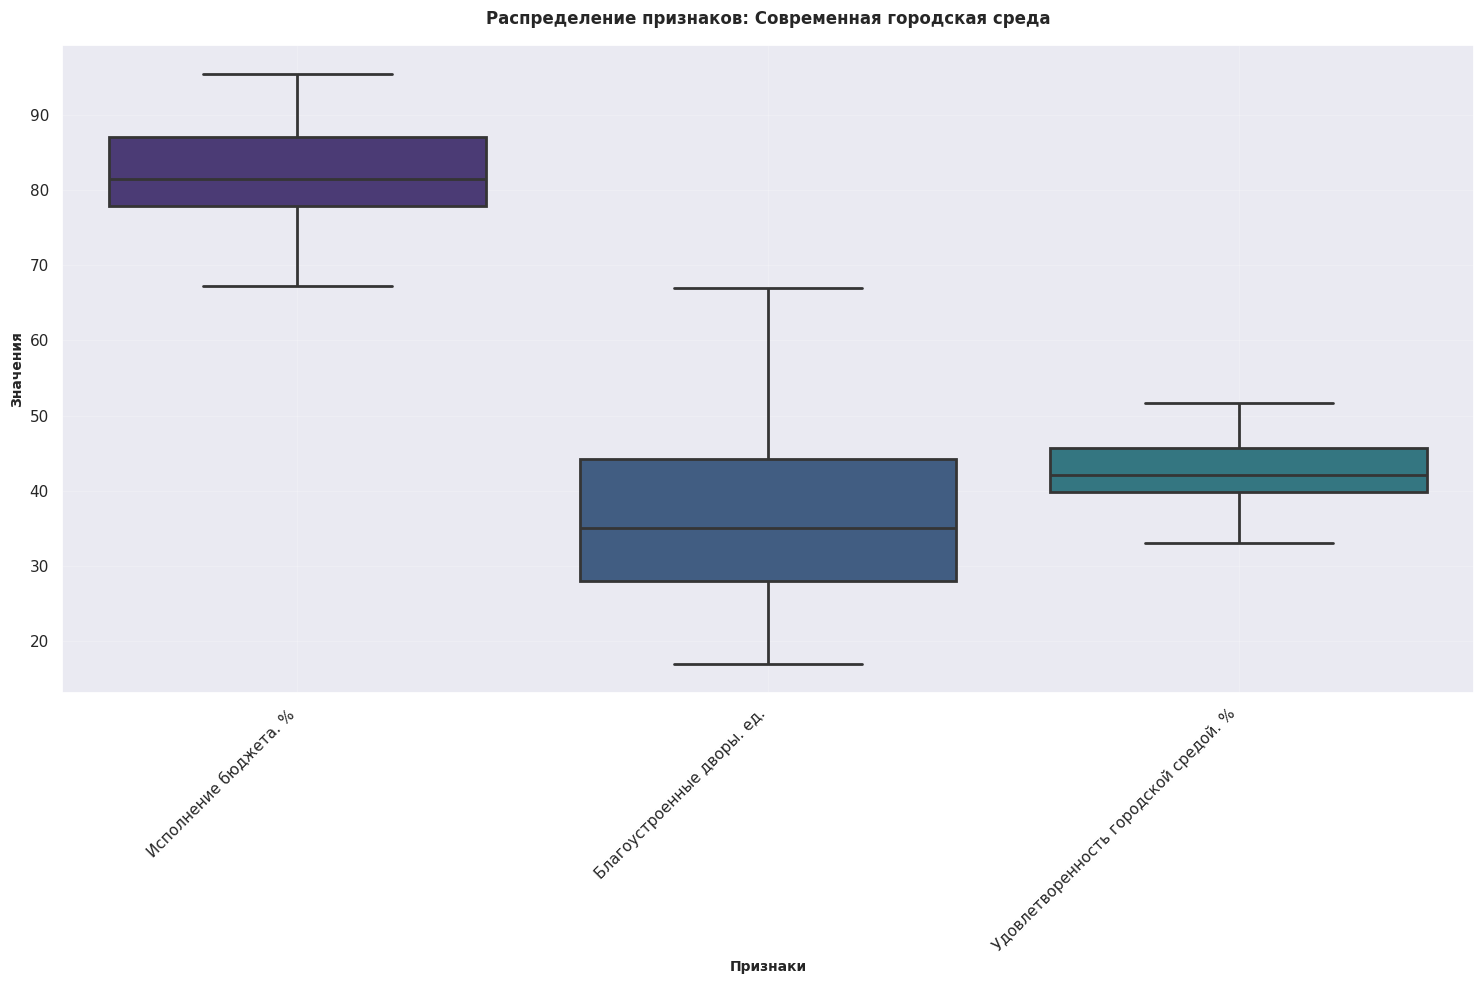

In [ ]:
d_urban_city_area = df.iloc[:, 4:7]
get_boxplot(d_urban_city_area, 'Современная городская среда')

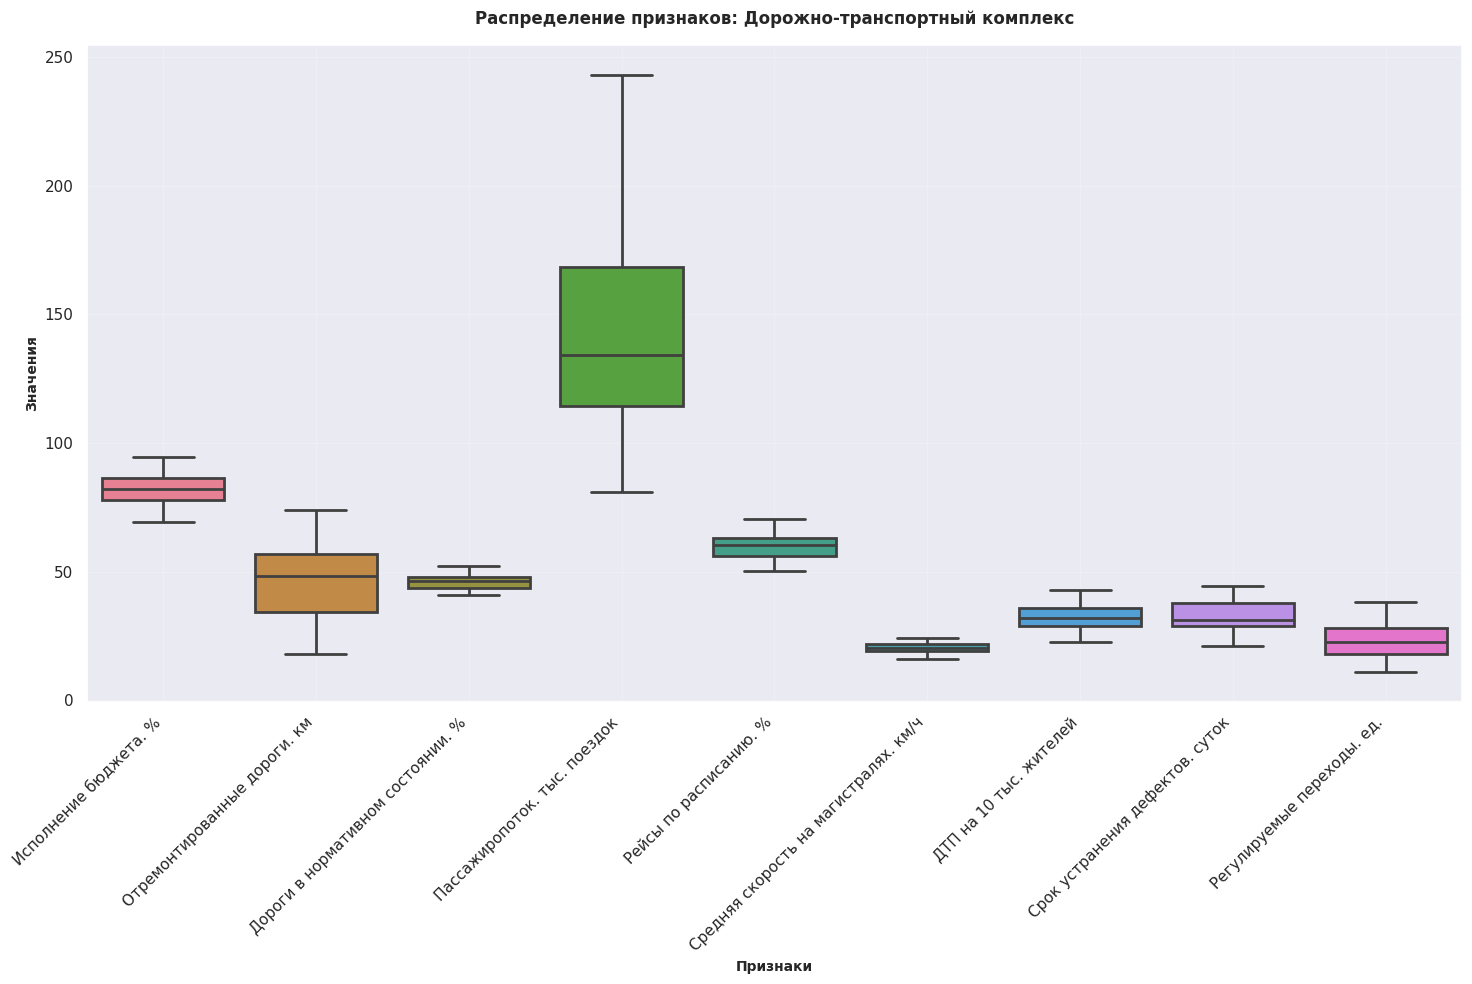

In [ ]:
d_road_transport_complex = df.iloc[:, 7:16]
get_boxplot(d_road_transport_complex, 'Дорожно-транспортный комплекс')

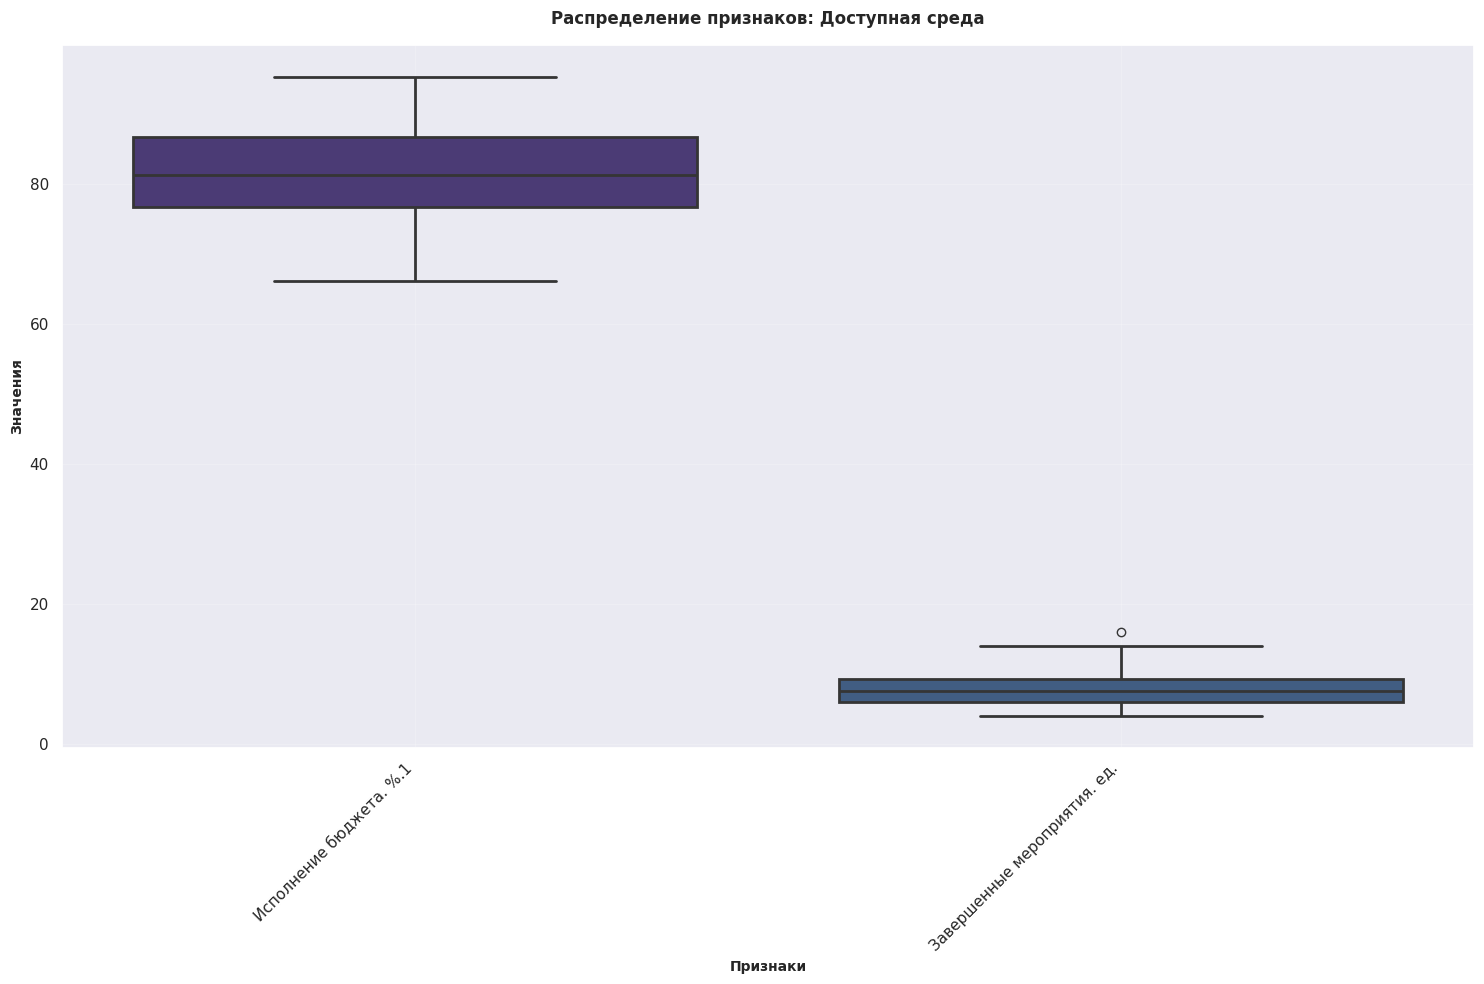

In [ ]:
d_available_area = df.iloc[:, 16:18]
get_boxplot(d_available_area, 'Доступная среда')

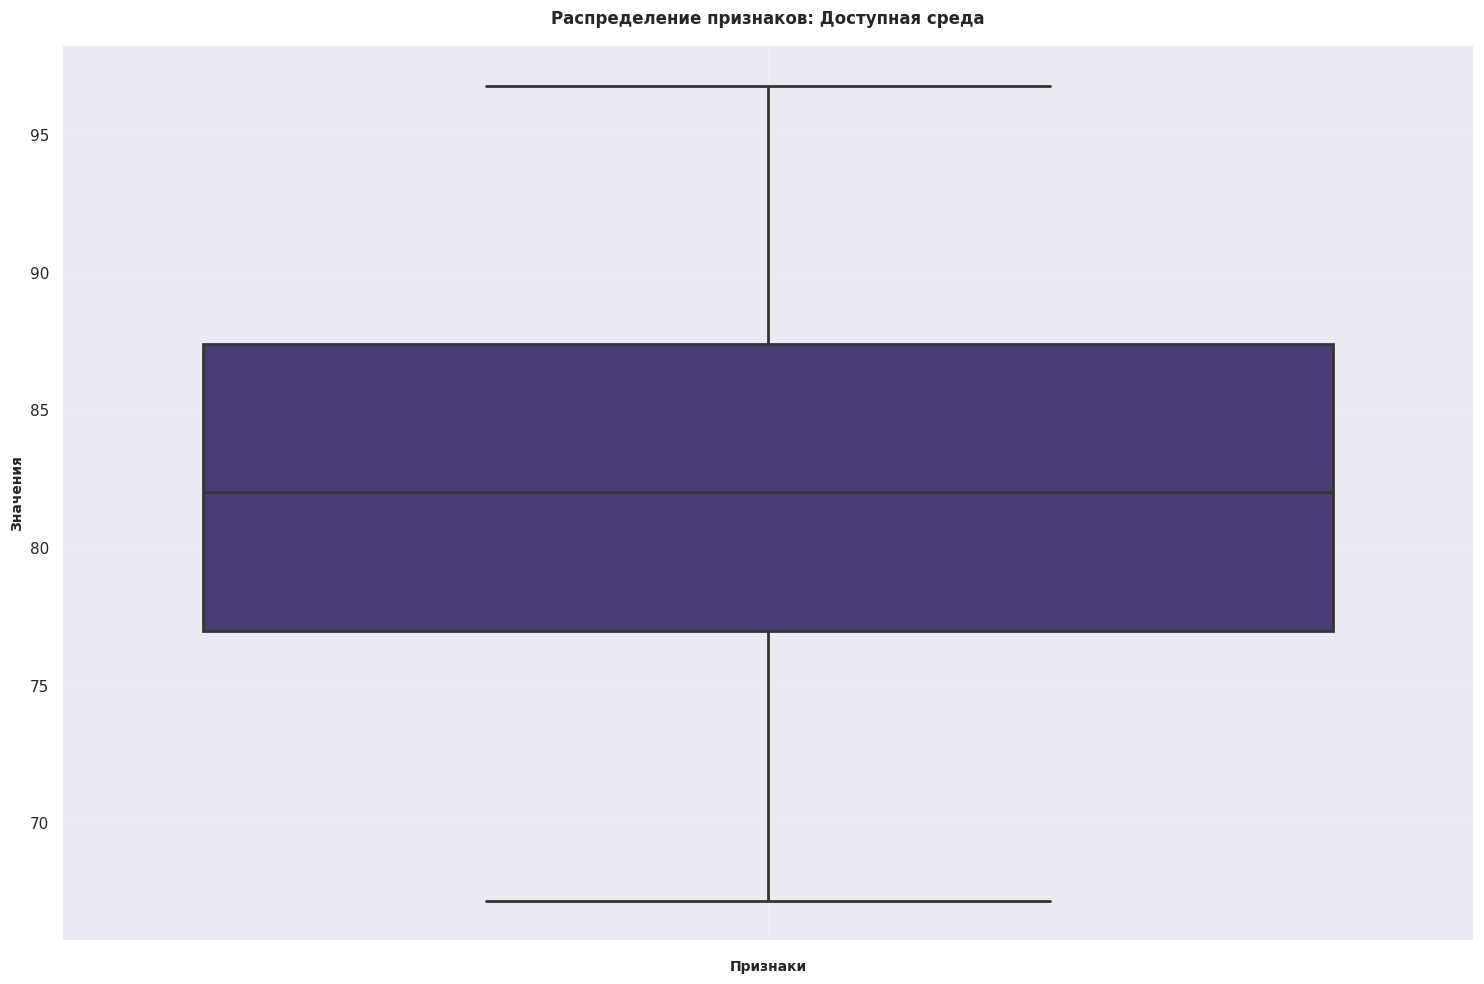

In [ ]:
support = df.iloc[:, 19]
get_boxplot(support, 'Доступная среда')

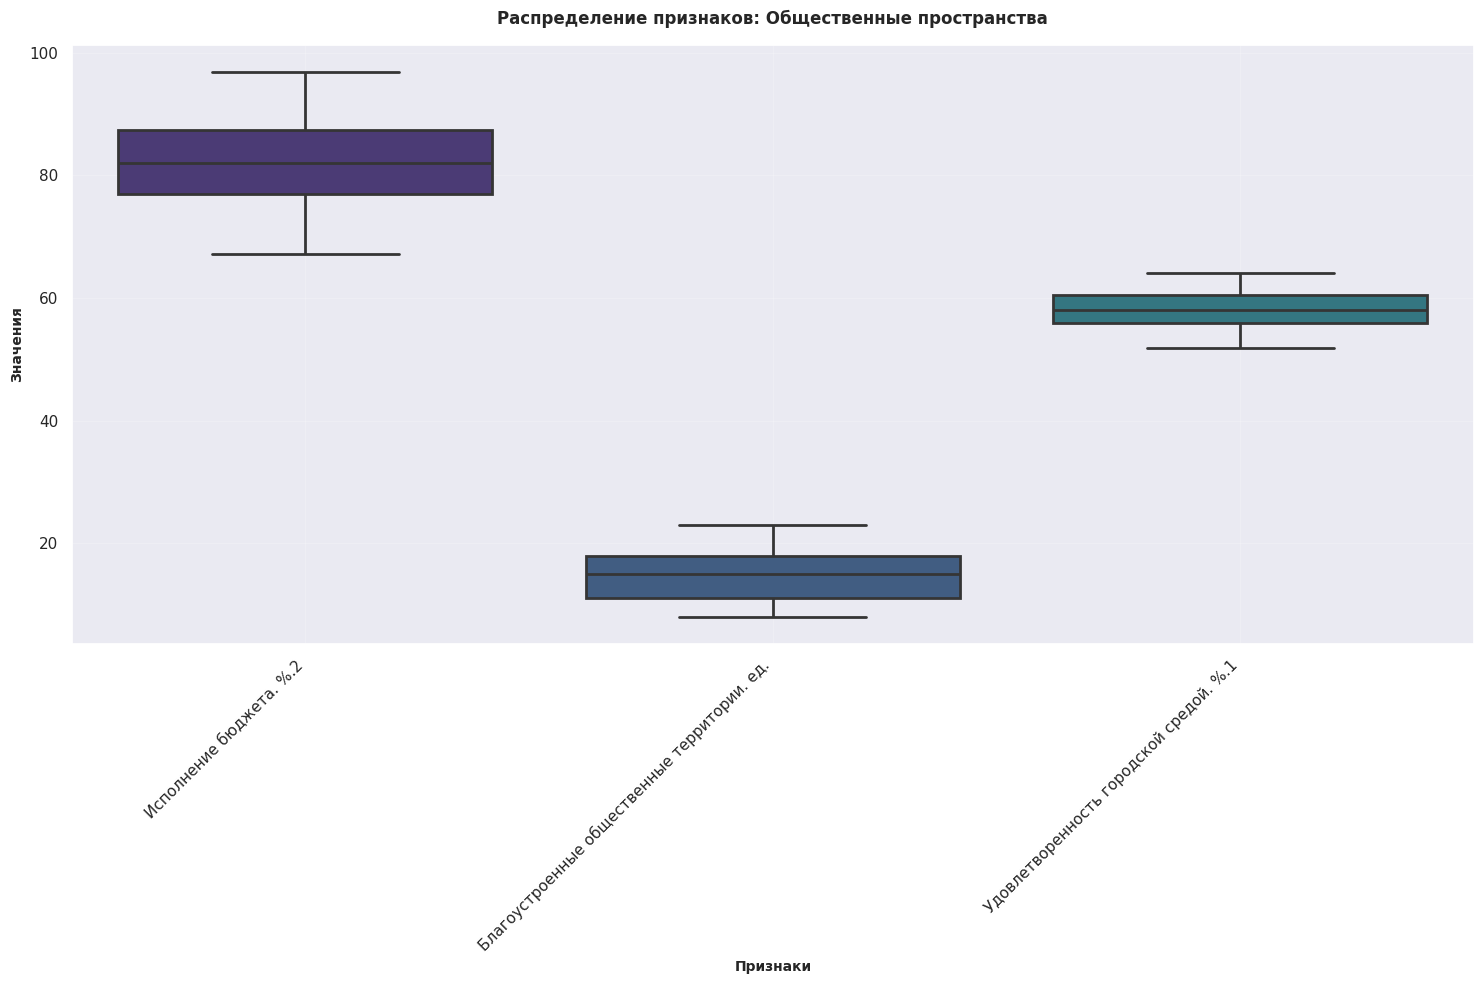

In [ ]:
d_public_spaces = df.iloc[:, 19:22]
get_boxplot(d_public_spaces, 'Общественные пространства')

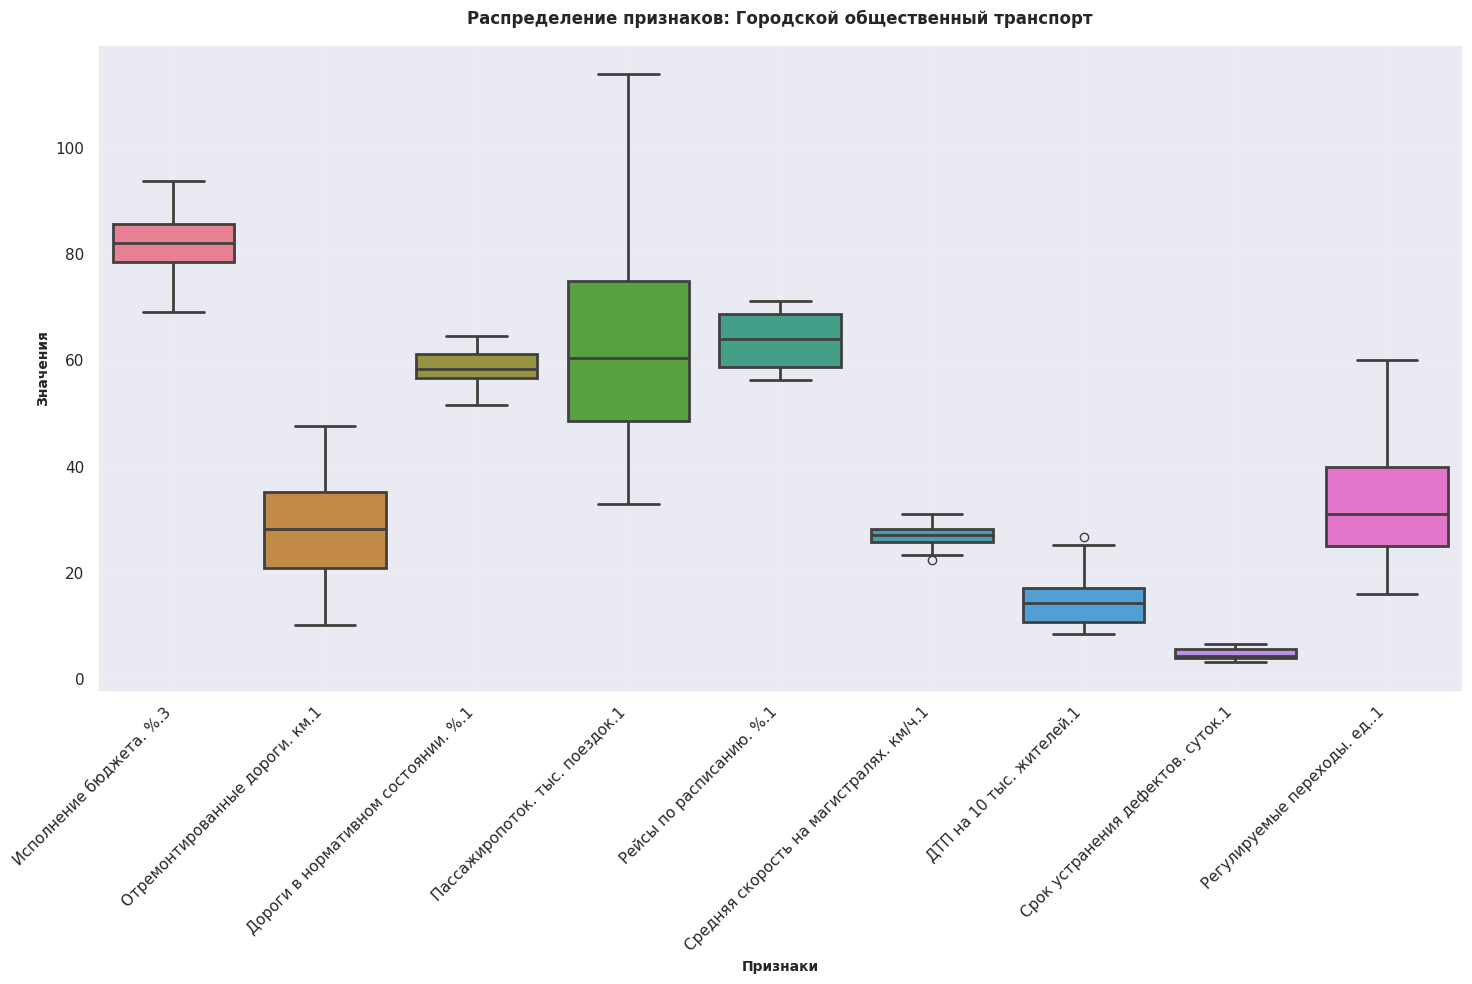

In [ ]:
d_city_public_transport = df.iloc[:, 22:31]
get_boxplot(d_city_public_transport, 'Городской общественный транспорт')

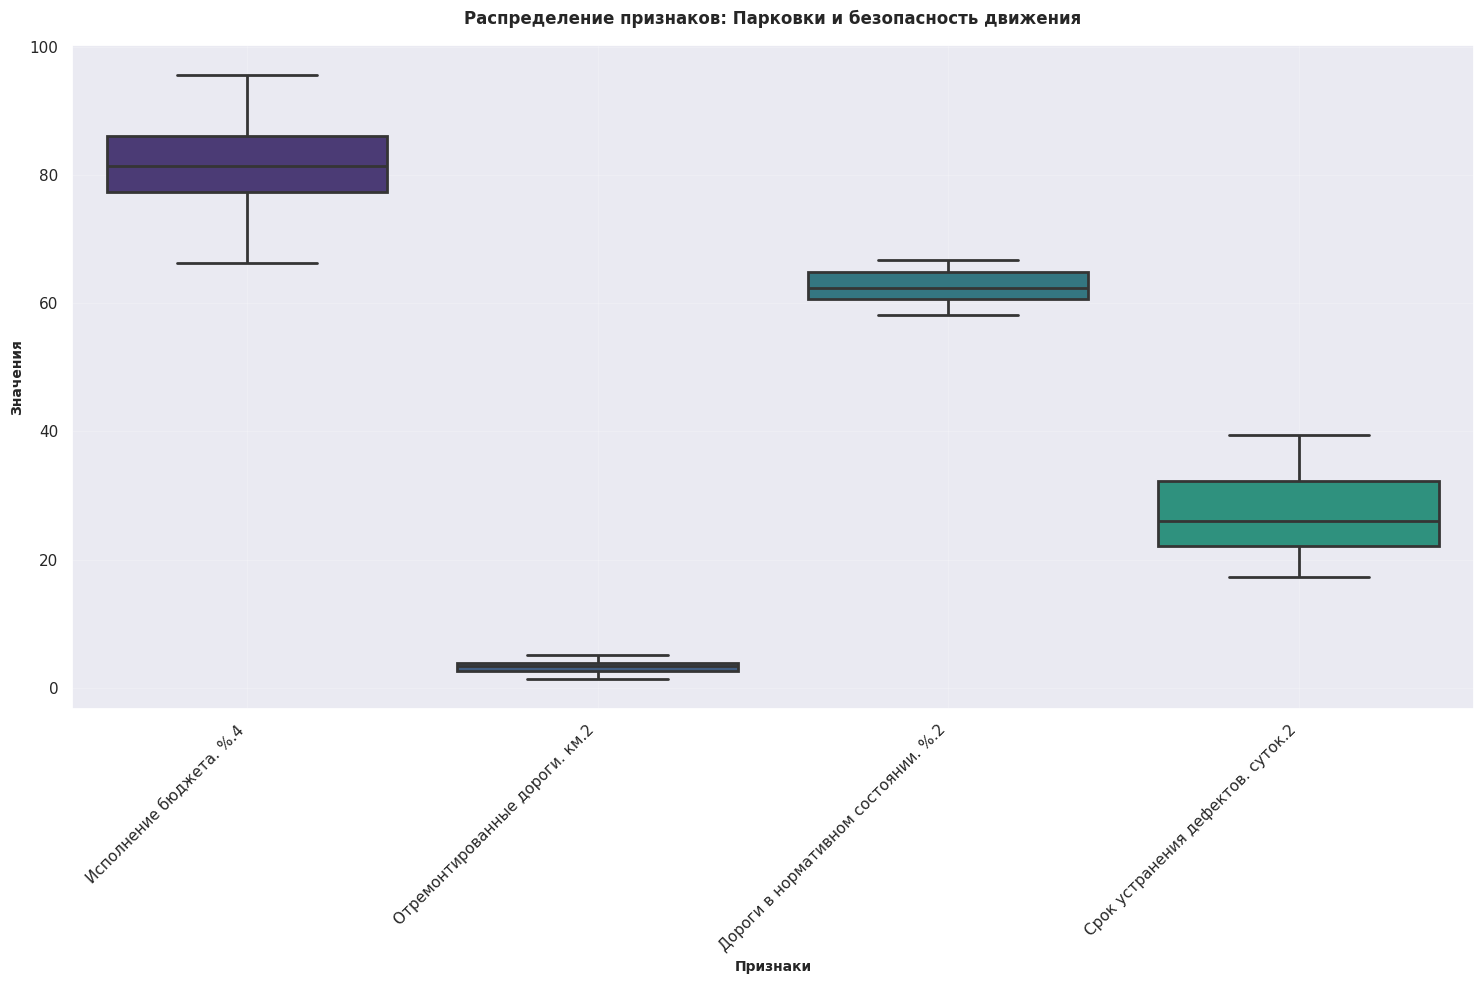

In [ ]:
d_parking_and_traffic_security = df.iloc[:, 31:]
get_boxplot(d_parking_and_traffic_security, 'Парковки и безопасность движения')

In [ ]:
# Логарифрирование признаков с преобладаем низких значений
df['Пассажиропоток. тыс. поездок.1'] = np.log1p(df['Пассажиропоток. тыс. поездок.1'])
df['Регулируемые переходы. ед..1'] = np.log1p(df['Регулируемые переходы. ед..1'])
df['ДТП на 10 тыс. жителей.1'] = np.log1p(df['ДТП на 10 тыс. жителей.1'])
df['Благоустроенные дворы. ед.'] = np.log1p(df['Благоустроенные дворы. ед.'])
df['Пассажиропоток. тыс. поездок'] = np.log1p(df['Пассажиропоток. тыс. поездок'])
df['Завершенные мероприятия. ед.'] = np.log1p(df['Завершенные мероприятия. ед.'])
df

,period_start,year,quarter,period_index,Исполнение бюджета. %,Благоустроенные дворы. ед.,Удовлетворенность городской средой. %,Исполнение бюджета. %,Отремонтированные дороги. км,Дороги в нормативном состоянии. %,...,Пассажиропоток. тыс. поездок.1,Рейсы по расписанию. %.1,Средняя скорость на магистралях. км/ч.1,ДТП на 10 тыс. жителей.1,Срок устранения дефектов. суток.1,Регулируемые переходы. ед..1,Исполнение бюджета. %.4,Отремонтированные дороги. км.2,Дороги в нормативном состоянии. %.2,Срок устранения дефектов. суток.2
0,2006-01-01,2006,1,1,69.0,2.890372,35.3,70.8,19.06,43.6,...,3.526361,58.0,25.6,3.321432,6.6,2.833213,66.3,1.47,59.9,37.9
1,2006-04-01,2006,2,2,75.8,3.218876,33.6,72.8,40.52,42.6,...,3.781914,57.2,23.5,3.214868,6.3,3.178054,75.1,3.35,62.0,38.0
2,2006-07-01,2006,3,3,76.6,3.465736,36.3,78.3,47.54,42.4,...,3.895894,57.9,27.2,3.126761,6.2,3.367296,79.0,3.89,60.8,36.1
3,2006-10-01,2006,4,4,86.0,3.526361,35.2,85.3,36.27,41.3,...,3.673766,58.5,27.5,3.131137,6.2,3.401197,84.1,2.97,61.4,36.4
4,2007-01-01,2007,1,5,71.2,2.944439,33.1,69.7,17.89,40.9,...,3.526361,58.4,27.4,3.265759,6.1,2.833213,72.4,1.51,58.7,39.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2024-10-01,2024,4,76,94.6,4.219508,49.6,94.4,55.11,50.0,...,4.436752,69.4,29.4,2.397895,3.4,4.060443,93.4,3.60,63.4,18.6
76,2025-01-01,2025,1,77,79.9,3.610918,49.7,79.1,26.45,50.1,...,4.316154,71.0,29.3,2.424803,3.2,3.465736,78.0,1.76,64.5,18.6
77,2025-04-01,2025,2,78,85.3,3.912023,48.8,87.4,57.95,50.4,...,4.619073,70.3,30.8,2.351375,3.2,3.850148,86.8,3.85,64.5,19.1
78,2025-07-01,2025,3,79,91.9,4.077537,49.6,87.5,71.69,52.3,...,4.743191,69.3,28.1,2.251292,3.3,4.025352,89.1,4.70,63.6,17.8


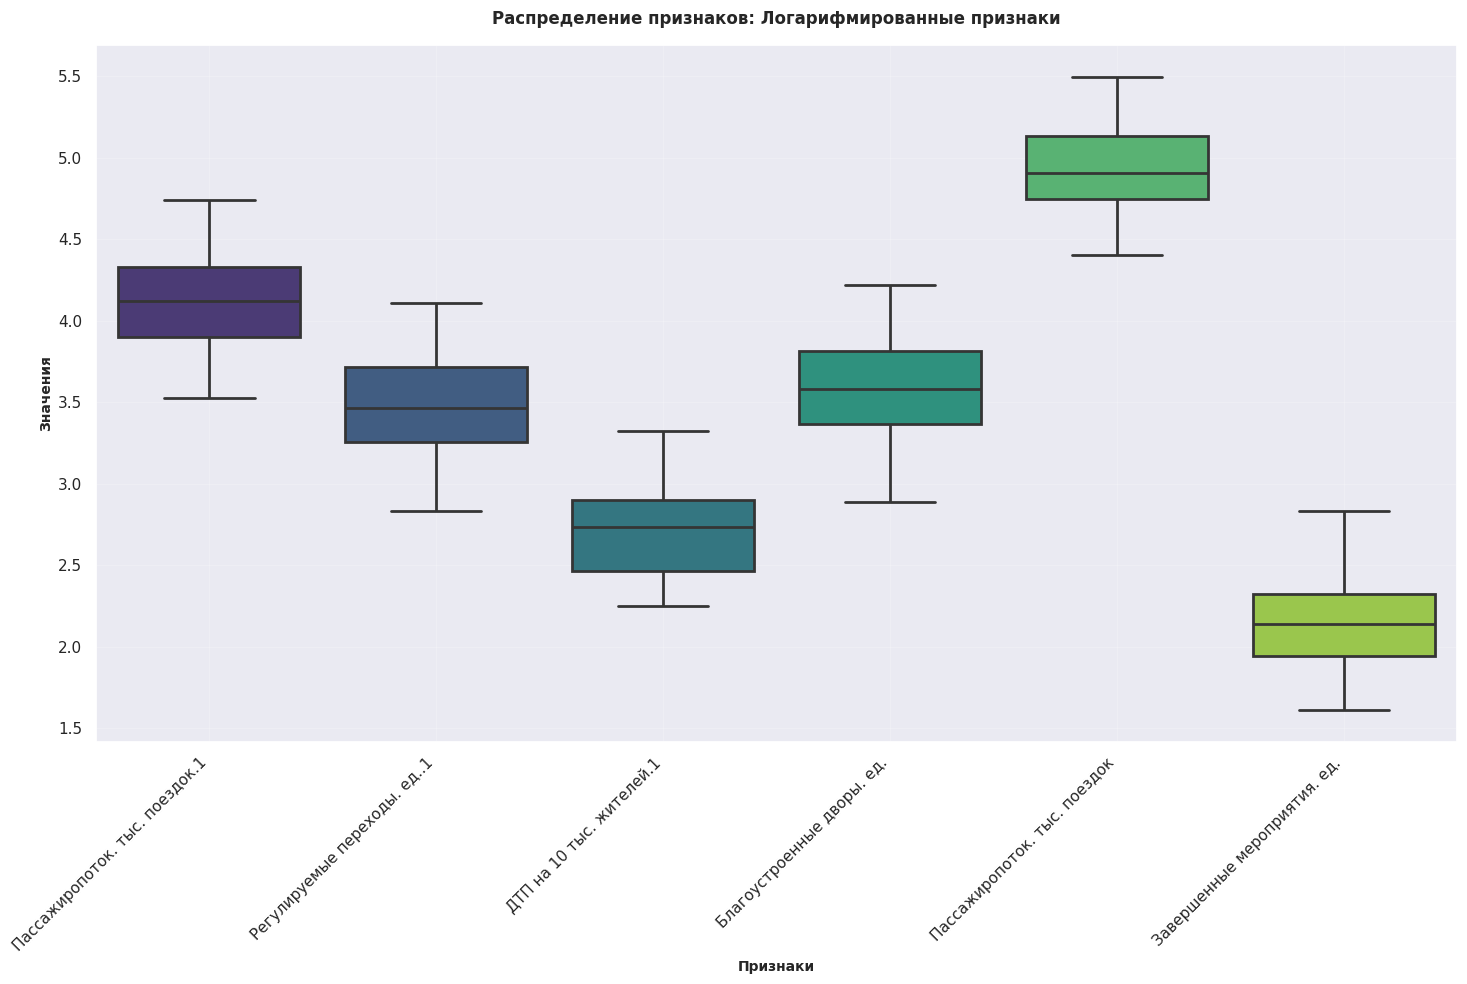

In [ ]:
log_features = df[['Пассажиропоток. тыс. поездок.1',
                  'Регулируемые переходы. ед..1',
                   'ДТП на 10 тыс. жителей.1',
                   'Благоустроенные дворы. ед.',
                   'Пассажиропоток. тыс. поездок',
                   'Завершенные мероприятия. ед.']]
get_boxplot(log_features, 'Логарифмированные признаки')

In [ ]:
# Избавление от выбросов признака "Средняя скорость на магистралях. км/ч.1"
Q1 = df['Средняя скорость на магистралях. км/ч.1'].quantile(0.25)
Q3 = df['Средняя скорость на магистралях. км/ч.1'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Средняя скорость на магистралях. км/ч.1'] < lower)
               | (df['Средняя скорость на магистралях. км/ч.1'] > upper)]
df.drop(outliers.index, axis=0, inplace=True)

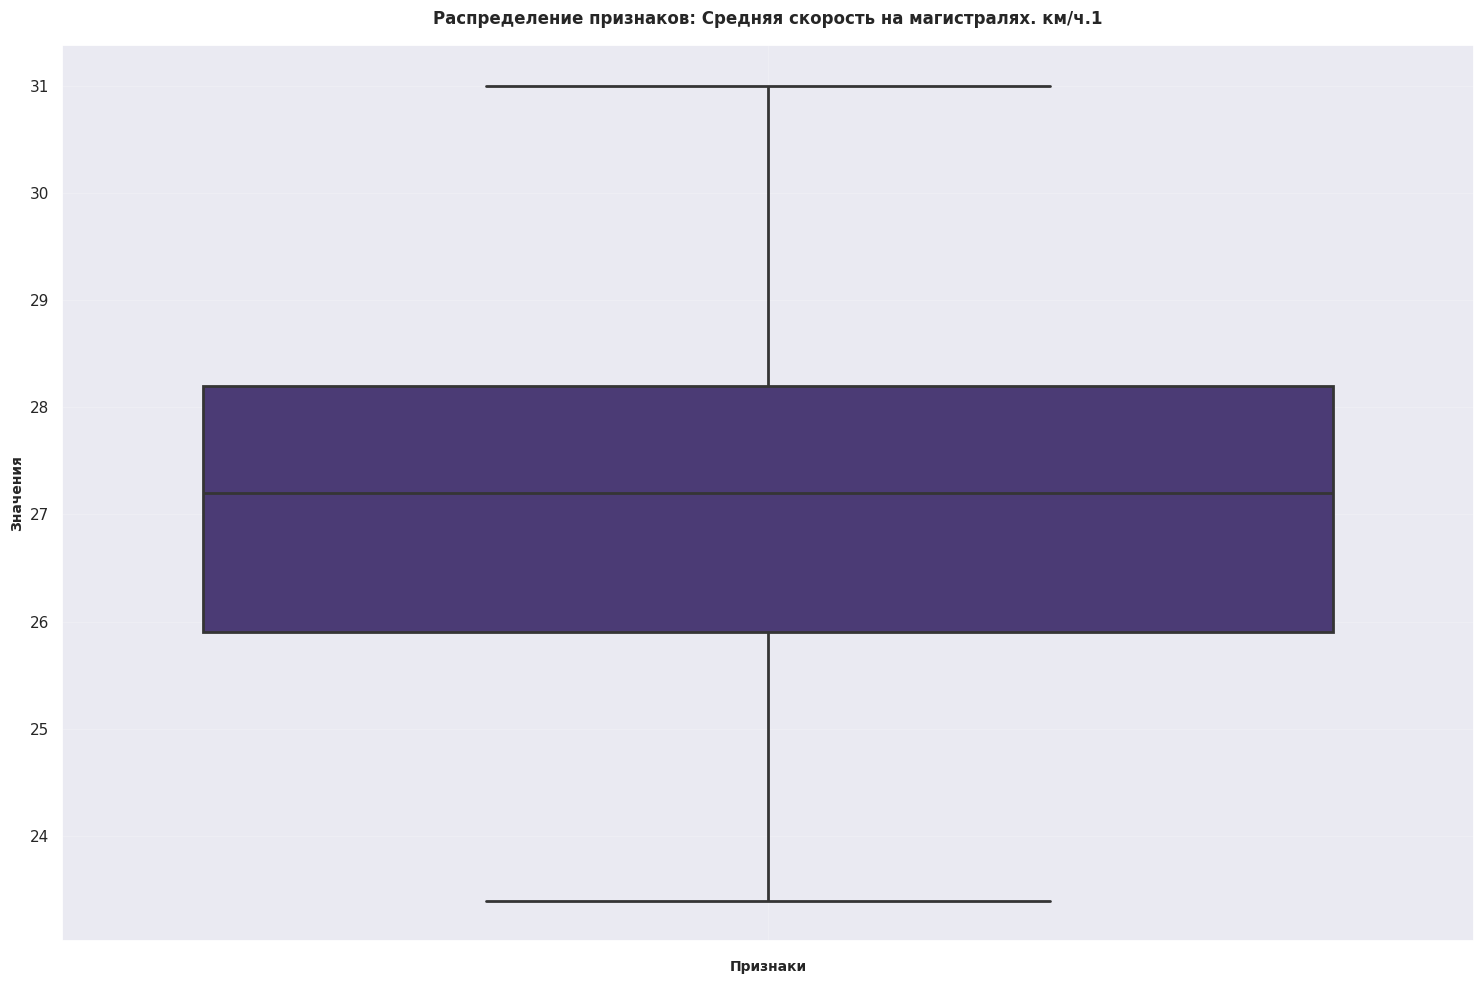

In [ ]:
get_boxplot(df['Средняя скорость на магистралях. км/ч.1'], 'Средняя скорость на магистралях. км/ч.1')

## **Подготовка инструментов для нечеткой свертки с лингвистическими переменными**

In [ ]:
class LinguisticVariable:

  """Описание лингвистических переменных"""
  def __init__(self, name, universe_min, universe_max):
      self.name = name
      self.universe_min = universe_min
      self.universe_max = universe_max
      self.terms = {}

  def add_term(self, term_name, mf_type, params):
      self.terms[term_name] = {'type': mf_type, 'params': params}

  def fuzzify(self, x, term_name):
      if term_name not in self.terms:
          raise ValueError(f"Терм '{term_name}' не найден")
      term = self.terms[term_name]
      if term['type'] == 'trimf':
          return trimf(x, *term['params'])
      elif term['type'] == 'trapmf':
          return trapmf(x, *term['params'])
      return 0.0

  def get_all_memberships(self, x):
      return {term: self.fuzzify(x, term) for term in self.terms}

  def plot(self, ax=None, points=1000):
      if ax is None:
          ax = plt.gca()
      x_vals = np.linspace(self.universe_min, self.universe_max, points)
      for term_name in self.terms:
          y_vals = [self.fuzzify(x, term_name) for x in x_vals]
          ax.plot(x_vals, y_vals, label=term_name, linewidth=2)
      ax.set_xlabel(self.name)
      ax.set_ylabel('Степень принадлежности')
      ax.set_title(self.name)
      ax.legend()
      ax.grid(True, alpha=0.3)
      return ax

In [ ]:
def trimf(x, a, b, c):
  """Треугольная функция"""
  if x <= a or x >= c:
    return 0.0
  elif a < x <= b:
    return (x - a) / (b - a) if b != a else 1.0
  else:
    return (c - x) / (c - b) if c != b else 1.0

In [ ]:
class FuzzySystem:

  """Описание нечеткой свертки с лингвистическими переменными"""
  def __init__(self):
      self.inputs = {}
      self.output = None
      self.rules = []

  def add_input(self, name, linguistic_var):
      self.inputs[name] = linguistic_var

  def set_output(self, name, linguistic_var):
      self.output = (name, linguistic_var)

  def add_rule(self, premise, consequent):
      self.rules.append({'premise': premise, 'consequent': consequent})

  def compute(self, inputs_values):
      if self.output is None:
          raise ValueError("Выходная переменная не установлена")

      # Фаззификация
      memberships = {}
      for inp_name, inp_var in self.inputs.items():
          x = inputs_values[inp_name]
          memberships[inp_name] = inp_var.get_all_memberships(x)

      # Активация правил
      rule_activations = []
      for rule in self.rules:
          activations = []
          for inp_name, term_name in rule['premise'].items():
              if inp_name in memberships:
                  mu = memberships[inp_name].get(term_name, 0)
                  activations.append(mu)
          if activations:
              rule_strength = min(activations)
              rule_activations.append({
                  'strength': rule_strength,
                  'consequent': rule['consequent']})

      # Агрегация
      output_name, output_var = self.output
      aggregated = {term: 0.0 for term in output_var.terms}
      for activation in rule_activations:
          strength = activation['strength']
          term_name = activation['consequent']
          if strength > aggregated.get(term_name, 0):
              aggregated[term_name] = strength

      # Дефаззификация
      return self._defuzzify(aggregated, output_var)

  def _defuzzify(self, aggregated, output_var):
      points = 1000
      x_vals = np.linspace(output_var.universe_min, output_var.universe_max, points)
      numerator = 0.0
      denominator = 0.0

      for x in x_vals:
          membership_values = []
          for term_name, agg_val in aggregated.items():
              if agg_val > 0:
                  mf_val = output_var.fuzzify(x, term_name)
                  membership_values.append(min(agg_val, mf_val))
          y = max(membership_values) if membership_values else 0.0
          numerator += x * y
          denominator += y

      return numerator / denominator if denominator > 0 else 0.0

In [ ]:
def apply_fuzzy_convolution(df):
  """Применение свертки к подготовленным данным"""
  return df.apply(
      lambda row: fuzzy_system.compute(row.to_dict()),
      axis=1
      ).values

## **Нечеткая свертка групп признаков с лингвистическими переменными**

### **Современная городская среда**

In [ ]:
# Выделяем sub_df для современной городской среды
urban_city_area = df.iloc[:, 4:7]
urban_city_area.rename(columns={'Исполнение бюджета. %': 'budget',
    'Благоустроенные дворы. ед.': 'yards',
    'Удовлетворенность городской средой. %': 'satisfaction'}, inplace=True)
urban_city_area

,budget,yards,satisfaction
0,69.0,2.890372,35.3
1,75.8,3.218876,33.6
2,76.6,3.465736,36.3
3,86.0,3.526361,35.2
4,71.2,2.944439,33.1
...,...,...,...
75,94.6,4.219508,49.6
76,79.9,3.610918,49.7
77,85.3,3.912023,48.8
78,91.9,4.077537,49.6


In [ ]:
urban_city_area.describe()

,budget,yards,satisfaction
count,79.000000,79.000000,79.000000
mean,81.953165,3.581273,42.262025
std,6.743769,0.327155,4.574800
min,67.300000,2.890372,33.100000
25%,77.850000,3.367296,39.800000
50%,81.300000,3.583519,42.100000
75%,87.150000,3.817652,45.700000
max,95.400000,4.219508,51.700000


In [ ]:
# Назначение лингвистических переменных
# Исполнение бюджета
budget_var = LinguisticVariable('Исполнение бюджета, %', 60, 100)
budget_var.add_term('очень_низкое', 'trimf', [60, 63, 68])
budget_var.add_term('низкое', 'trimf', [65, 70, 75])
budget_var.add_term('среднее', 'trimf', [72, 78, 84])
budget_var.add_term('высокое', 'trimf', [80, 86, 92])
budget_var.add_term('очень_высокое', 'trimf', [88, 94, 100])

# Благоустроенные дворы
yards_var = LinguisticVariable('Благоустроенные дворы, ед.', np.log1p(10),
                               np.log1p(70))
yards_var.add_term('очень_мало', 'trimf', np.log1p([10, 15, 22]).tolist())
yards_var.add_term('мало', 'trimf', np.log1p([18, 25, 32]).tolist())
yards_var.add_term('средне', 'trimf', np.log1p([28, 35, 42]).tolist())
yards_var.add_term('много', 'trimf', np.log1p([38, 45, 52]).tolist())
yards_var.add_term('очень_много', 'trimf', np.log1p([48, 55, 70]).tolist())

# Удовлетворенность городской средойтворенность
satisfaction_var = LinguisticVariable('Удовлетворенность городской средой, %',
                                      30, 60)
satisfaction_var.add_term('очень_низкая', 'trimf', [30, 33, 37])
satisfaction_var.add_term('низкая', 'trimf', [34, 38, 42])
satisfaction_var.add_term('средняя', 'trimf', [39, 43, 47])
satisfaction_var.add_term('высокая', 'trimf', [44, 48, 52])
satisfaction_var.add_term('очень_высокая', 'trimf', [49, 53, 60])

# Индекс качества современной городской среды
quality_var = LinguisticVariable('Индекс качества СГС', 1, 100)
quality_var.add_term('катастрофа', 'trimf', [1, 5, 20])
quality_var.add_term('плохое', 'trimf', [15, 28, 40])
quality_var.add_term('удовлетворительное', 'trimf', [35, 50, 65])
quality_var.add_term('хорошее', 'trimf', [60, 72, 84])
quality_var.add_term('отличное', 'trimf', [78, 88, 95])
quality_var.add_term('превосходное', 'trimf', [90, 97, 100])

In [ ]:
import json

# Получение правил соответствующей группы признаков
def get_rules(filename):
    with open(filename, 'r', encoding='utf-8') as f:
        loaded_rules = json.load(f)

    return [tuple(rule) for rule in loaded_rules]

In [ ]:
# Указание правил
fuzzy_system = FuzzySystem()
fuzzy_system.add_input('budget', budget_var)
fuzzy_system.add_input('yards', yards_var)
fuzzy_system.add_input('satisfaction', satisfaction_var)
fuzzy_system.set_output('quality_index', quality_var)

rules = get_rules('urban_city_area_rules.json')

for premise, consequent in rules:
    fuzzy_system.add_rule(premise, consequent)

In [ ]:
rules[0]

({'budget': 'очень_низкое',
  'yards': 'очень_мало',
  'satisfaction': 'очень_низкая'},
 'катастрофа')

In [ ]:
urban_city_area['Индекс качества современной городской среды'] = apply_fuzzy_convolution(urban_city_area)
urban_city_area

,budget,yards,satisfaction,Индекс качества современной городской среды
0,69.0,2.890372,35.3,9.436601
1,75.8,3.218876,33.6,27.633917
2,76.6,3.465736,36.3,44.039041
3,86.0,3.526361,35.2,50.000019
4,71.2,2.944439,33.1,9.224932
...,...,...,...,...
75,94.6,4.219508,49.6,88.942518
76,79.9,3.610918,49.7,55.017935
77,85.3,3.912023,48.8,75.019430
78,91.9,4.077537,49.6,87.910323


In [ ]:
urban_city_area.describe()

,budget,yards,satisfaction,Индекс качества современной городской среды
count,79.000000,79.000000,79.000000,79.000000
mean,81.953165,3.581273,42.262025,53.263191
std,6.743769,0.327155,4.574800,20.953356
min,67.300000,2.890372,33.100000,9.224932
25%,77.850000,3.367296,39.800000,41.331475
50%,81.300000,3.583519,42.100000,50.000031
75%,87.150000,3.817652,45.700000,68.466738
max,95.400000,4.219508,51.700000,91.759397


#### **Графики треугольных функций на основе одной из групп признаков**

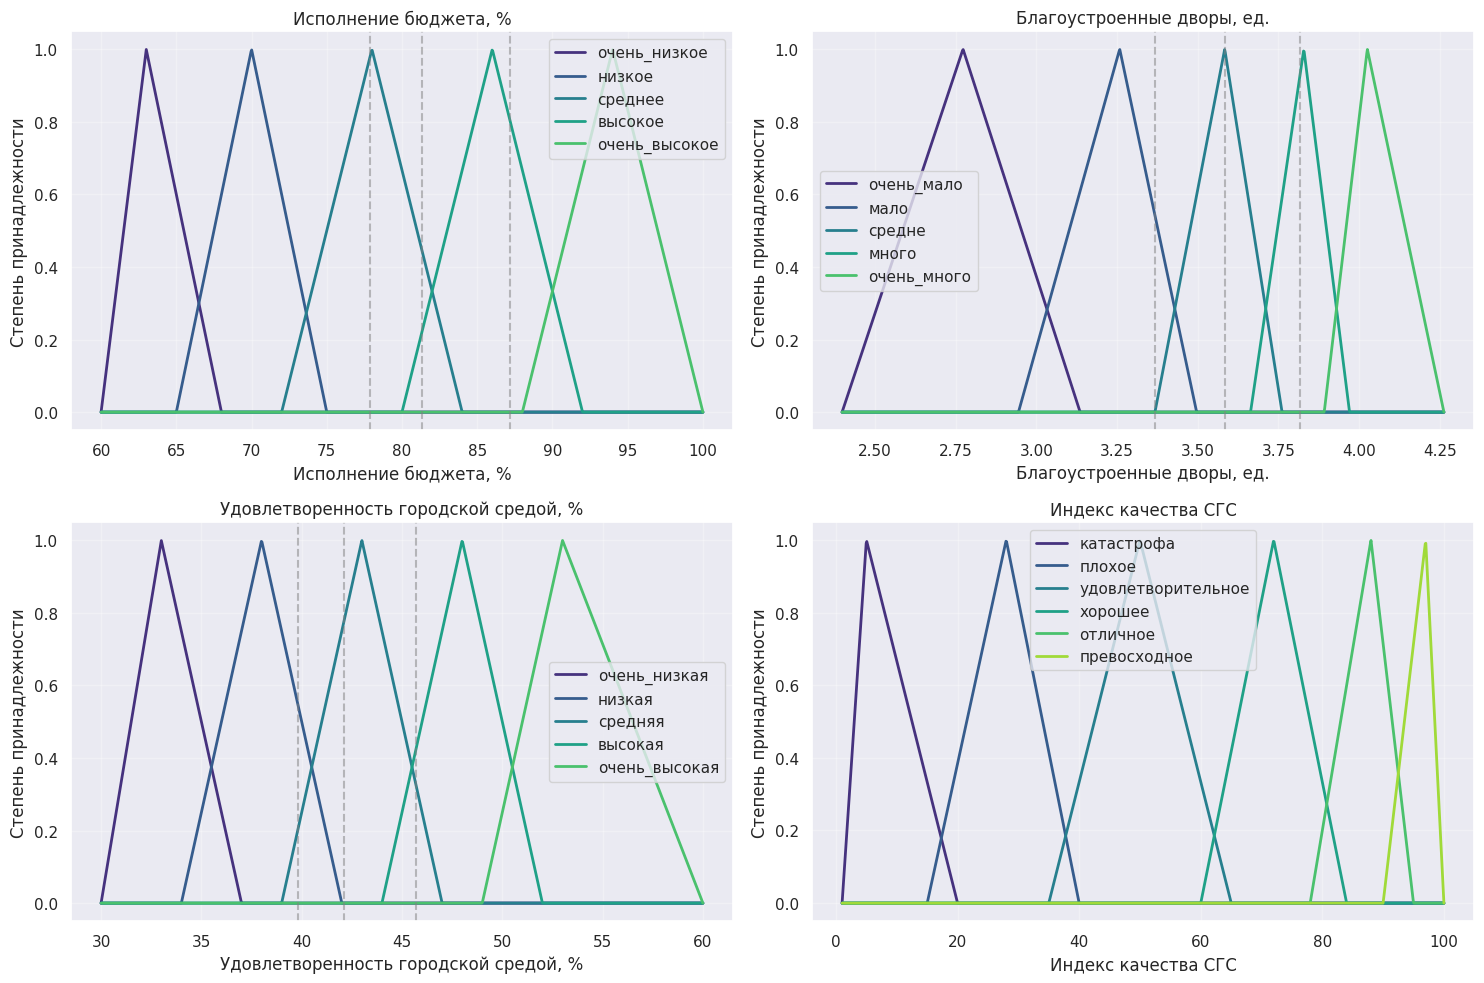

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

budget_var.plot(ax=axes[0, 0])
for q in [0.25, 0.5, 0.75]:
    val = df['Исполнение бюджета. %'].quantile(q)
    if hasattr(val, 'values'):
        val = val.values[0] if len(val.values) > 0 else None
    if val is not None:
        axes[0, 0].axvline(val, color='gray', linestyle='--', alpha=0.5,
                           label=f'Q{q:.0%}: {val:.1f}')

yards_var.plot(ax=axes[0, 1])
for q in [0.25, 0.5, 0.75]:
    val = df['Благоустроенные дворы. ед.'].quantile(q)
    if hasattr(val, 'values'):
        val = val.values[0] if len(val.values) > 0 else None
    if val is not None:
        axes[0, 1].axvline(val, color='gray', linestyle='--', alpha=0.5,
                           label=f'Q{q:.0%}: {val:.1f}')

satisfaction_var.plot(ax=axes[1, 0])
for q in [0.25, 0.5, 0.75]:
    val = df['Удовлетворенность городской средой. %'].quantile(q)
    if hasattr(val, 'values'):
        val = val.values[0] if len(val.values) > 0 else None
    if val is not None:
        axes[1, 0].axvline(val, color='gray', linestyle='--', alpha=0.5,
                           label=f'Q{q:.0%}: {val:.1f}')

quality_var.plot(ax=axes[1, 1])
plt.tight_layout()

### **Дорожно-транспортный комплекс**

In [ ]:
road_transport_complex = df.iloc[:, 7:16]
road_transport_complex

,Исполнение бюджета. %,Отремонтированные дороги. км,Дороги в нормативном состоянии. %,Пассажиропоток. тыс. поездок,Рейсы по расписанию. %,Средняя скорость на магистралях. км/ч,ДТП на 10 тыс. жителей,Срок устранения дефектов. суток,Регулируемые переходы. ед.
0,70.8,19.06,43.6,4.456670,52.7,22.0,42.3,44.4,11.0
1,72.8,40.52,42.6,4.722953,52.0,22.6,39.0,42.0,16.0
2,78.3,47.54,42.4,4.843399,51.6,19.7,37.3,41.5,18.0
3,85.3,36.27,41.3,4.621044,52.8,20.0,40.0,40.7,20.0
4,69.7,17.89,40.9,4.494239,52.7,22.2,40.5,40.7,11.0
...,...,...,...,...,...,...,...,...,...
75,94.4,55.11,50.0,5.238036,67.0,18.5,27.3,24.0,37.0
76,79.1,26.45,50.1,5.129307,70.0,18.4,30.4,24.9,20.0
77,87.4,57.95,50.4,5.431974,68.4,18.0,25.8,21.1,29.0
78,87.5,71.69,52.3,5.485212,70.6,21.8,22.6,23.3,35.0


In [ ]:
road_transport_complex.describe()

,Исполнение бюджета. %,Отремонтированные дороги. км,Дороги в нормативном состоянии. %,Пассажиропоток. тыс. поездок,Рейсы по расписанию. %,Средняя скорость на магистралях. км/ч,ДТП на 10 тыс. жителей,Срок устранения дефектов. суток,Регулируемые переходы. ед.
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,82.029114,45.181013,46.035443,4.932209,60.081013,20.378481,32.598734,32.875949,23.253165
std,6.382170,15.448880,2.762154,0.258441,5.108366,1.843260,4.588433,5.632489,7.195918
min,69.300000,17.890000,40.900000,4.405499,50.300000,16.000000,22.600000,21.100000,11.000000
25%,77.650000,31.960000,43.550000,4.747103,55.900000,19.050000,29.100000,28.950000,18.000000
50%,82.100000,47.950000,46.500000,4.902307,60.400000,20.400000,32.200000,31.800000,22.000000
75%,86.400000,56.405000,48.000000,5.114891,62.950000,21.750000,35.950000,38.000000,28.000000
max,94.500000,73.970000,52.300000,5.497578,70.600000,24.000000,42.700000,44.400000,38.000000


In [ ]:
road_transport_complex_r1 = road_transport_complex.drop(
    ['Дороги в нормативном состоянии. %',
     'Исполнение бюджета. %',
     'Регулируемые переходы. ед.'], axis=1)
road_transport_complex_r1.rename(columns={
    'Отремонтированные дороги. км': 'roads',
    'Пассажиропоток. тыс. поездок': 'passenger',
    'Рейсы по расписанию. %': 'schedule',
    'Средняя скорость на магистралях. км/ч': 'speed',
    'ДТП на 10 тыс. жителей': 'accident',
    'Срок устранения дефектов. суток': 'defect',
}, inplace=True)
road_transport_complex_r1

,roads,passenger,schedule,speed,accident,defect
0,19.06,4.456670,52.7,22.0,42.3,44.4
1,40.52,4.722953,52.0,22.6,39.0,42.0
2,47.54,4.843399,51.6,19.7,37.3,41.5
3,36.27,4.621044,52.8,20.0,40.0,40.7
4,17.89,4.494239,52.7,22.2,40.5,40.7
...,...,...,...,...,...,...
75,55.11,5.238036,67.0,18.5,27.3,24.0
76,26.45,5.129307,70.0,18.4,30.4,24.9
77,57.95,5.431974,68.4,18.0,25.8,21.1
78,71.69,5.485212,70.6,21.8,22.6,23.3


In [ ]:
road_transport_complex_r1.describe()

,roads,passenger,schedule,speed,accident,defect
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,45.181013,4.932209,60.081013,20.378481,32.598734,32.875949
std,15.448880,0.258441,5.108366,1.843260,4.588433,5.632489
min,17.890000,4.405499,50.300000,16.000000,22.600000,21.100000
25%,31.960000,4.747103,55.900000,19.050000,29.100000,28.950000
50%,47.950000,4.902307,60.400000,20.400000,32.200000,31.800000
75%,56.405000,5.114891,62.950000,21.750000,35.950000,38.000000
max,73.970000,5.497578,70.600000,24.000000,42.700000,44.400000


In [ ]:
# Отремонтированные дороги
roads_var = LinguisticVariable('Отремонтированные дороги, км', 15, 75)
roads_var.add_term('мало', 'trimf', [15, 25, 45])
roads_var.add_term('средне', 'trimf', [35, 55, 65])
roads_var.add_term('много', 'trimf', [50, 65, 75])

# Пассажиропоток
passenger_var = LinguisticVariable('Пассажиропоток, тыс. поездок', np.log1p(80),
    np.log1p(245))
passenger_var.add_term('низкий', 'trimf', np.log1p([80, 95, 130]).tolist())
passenger_var.add_term('средний', 'trimf', np.log1p([115, 150, 185]).tolist())
passenger_var.add_term('высокий', 'trimf', np.log1p([165, 200, 245]).tolist())

# Рейсы по расписанию
schedule_var = LinguisticVariable('Рейсы по расписанию, %', 48, 73)
schedule_var.add_term('низкое', 'trimf', [48, 52, 57])
schedule_var.add_term('среднее', 'trimf', [55, 60, 65])
schedule_var.add_term('высокое', 'trimf', [63, 68, 73])

# Средняя скорость
speed_var = LinguisticVariable('Средняя скорость, км/ч', 13, 27)
speed_var.add_term('низкая',  'trimf', [13, 16, 19])
speed_var.add_term('средняя', 'trimf', [18, 20, 22])
speed_var.add_term('высокая', 'trimf', [21, 24, 27])

# ДТП на 10 тыс. жителей
accident_var = LinguisticVariable('ДТП на 10 тыс. жителей', 22, 44)
accident_var.add_term('низкое', 'trimf', [22, 25, 29])
accident_var.add_term('среднее', 'trimf', [27, 32, 37])
accident_var.add_term('высокое', 'trimf', [34, 39, 44])

# Срок устранения дефектов
defect_var = LinguisticVariable('Срок устранения дефектов, сут', 20, 46)
defect_var.add_term('быстро', 'trimf', [20, 24, 30])
defect_var.add_term('средне', 'trimf', [28, 33, 38])
defect_var.add_term('медленно', 'trimf', [35, 41, 46])

# Индекс качества дорог
quality_var = LinguisticVariable('Индекс качества дорог', 1, 100)
quality_var.add_term('катастрофа', 'trimf', [1, 5, 20])
quality_var.add_term('плохое', 'trimf', [15, 28, 40])
quality_var.add_term('удовлетворительное', 'trimf', [35, 50, 65])
quality_var.add_term('хорошее', 'trimf', [60, 72, 84])
quality_var.add_term('отличное', 'trimf', [78, 88, 95])
quality_var.add_term('превосходное', 'trimf', [90, 97, 100])

In [ ]:
# Указание правил
fuzzy_system = FuzzySystem()
fuzzy_system.add_input('roads', roads_var)
fuzzy_system.add_input('passenger', passenger_var)
fuzzy_system.add_input('speed', speed_var)
fuzzy_system.add_input('schedule', schedule_var)
fuzzy_system.add_input('accident', accident_var)
fuzzy_system.add_input('defect', defect_var)
fuzzy_system.set_output('quality_index', quality_var)

rules = get_rules('transport_r1_rules.json')

for premise, consequent in rules:
    fuzzy_system.add_rule(premise, consequent)

In [ ]:
road_transport_complex_r1['Индекс качества дорог'] = apply_fuzzy_convolution(road_transport_complex_r1)
road_transport_complex_r1

,roads,passenger,schedule,speed,accident,defect,Индекс качества дорог
0,19.06,4.456670,52.7,22.0,42.3,44.4,27.574972
1,40.52,4.722953,52.0,22.6,39.0,42.0,27.553680
2,47.54,4.843399,51.6,19.7,37.3,41.5,0.000000
3,36.27,4.621044,52.8,20.0,40.0,40.7,9.411691
4,17.89,4.494239,52.7,22.2,40.5,40.7,27.568168
...,...,...,...,...,...,...,...
75,55.11,5.238036,67.0,18.5,27.3,24.0,0.000000
76,26.45,5.129307,70.0,18.4,30.4,24.9,75.250673
77,57.95,5.431974,68.4,18.0,25.8,21.1,0.000000
78,71.69,5.485212,70.6,21.8,22.6,23.3,0.000000


In [ ]:
road_transport_complex_r1.describe()

,roads,passenger,schedule,speed,accident,defect,Индекс качества дорог
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,45.181013,4.932209,60.081013,20.378481,32.598734,32.875949,19.233400
std,15.448880,0.258441,5.108366,1.843260,4.588433,5.632489,24.548001
min,17.890000,4.405499,50.300000,16.000000,22.600000,21.100000,0.000000
25%,31.960000,4.747103,55.900000,19.050000,29.100000,28.950000,0.000000
50%,47.950000,4.902307,60.400000,20.400000,32.200000,31.800000,9.411691
75%,56.405000,5.114891,62.950000,21.750000,35.950000,38.000000,27.596714
max,73.970000,5.497578,70.600000,24.000000,42.700000,44.400000,86.795321


In [ ]:
road_transport_complex_r2 = road_transport_complex[['Дороги в нормативном состоянии. %',
                                                    'Исполнение бюджета. %',
                                                    'Регулируемые переходы. ед.']]
road_transport_complex_r2.rename(columns={
    'Исполнение бюджета. %': 'budget',
    'Дороги в нормативном состоянии. %': 'norm',
    'Регулируемые переходы. ед.': 'crossing'}, inplace=True)
road_transport_complex_r2

/tmp/ipykernel_1196/3261699982.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  road_transport_complex_r2.rename(columns={


,norm,budget,crossing
0,43.6,70.8,11.0
1,42.6,72.8,16.0
2,42.4,78.3,18.0
3,41.3,85.3,20.0
4,40.9,69.7,11.0
...,...,...,...
75,50.0,94.4,37.0
76,50.1,79.1,20.0
77,50.4,87.4,29.0
78,52.3,87.5,35.0


In [ ]:
road_transport_complex_r2.describe()

,norm,budget,crossing
count,79.000000,79.000000,79.000000
mean,46.035443,82.029114,23.253165
std,2.762154,6.382170,7.195918
min,40.900000,69.300000,11.000000
25%,43.550000,77.650000,18.000000
50%,46.500000,82.100000,22.000000
75%,48.000000,86.400000,28.000000
max,52.300000,94.500000,38.000000


In [ ]:
# Дороги в нормативном состоянии
norm_var = LinguisticVariable('Дороги в нормативном состоянии, %', 40, 53)
norm_var.add_term('очень_низкое', 'trimf', [40, 41.5, 43.5])
norm_var.add_term('низкое', 'trimf', [42, 44, 46])
norm_var.add_term('среднее', 'trimf', [44.5, 46.5, 48.5])
norm_var.add_term('высокое', 'trimf', [47, 49, 51])
norm_var.add_term('очень_высокое', 'trimf', [49.5, 51.5, 53])

# Исполнение бюджета
budget_var = LinguisticVariable('Исполнение бюджета, %', 68, 96)
budget_var.add_term('очень_низкий', 'trimf', [68, 70.5, 75])
budget_var.add_term('низкий', 'trimf', [73, 77, 81])
budget_var.add_term('средний', 'trimf', [79, 83, 87])
budget_var.add_term('высокий', 'trimf', [85, 88.5, 92])
budget_var.add_term('очень_высокий', 'trimf', [90, 93, 96])

# Регулируемые переходы
crossing_var = LinguisticVariable('Регулируемые переходы, ед.', 10, 40)
crossing_var.add_term('очень_мало', 'trimf', [10, 13, 18])
crossing_var.add_term('мало', 'trimf', [15, 20, 25])
crossing_var.add_term('средне', 'trimf', [22, 27, 32])
crossing_var.add_term('много', 'trimf', [28, 33, 36])
crossing_var.add_term('очень_много', 'trimf', [34, 37, 40])

# Индекс благополучия дорог
quality_var = LinguisticVariable('Индекс качества дорог', 1, 100)
quality_var.add_term('катастрофа', 'trimf', [1, 5, 20])
quality_var.add_term('плохое', 'trimf', [15, 28, 40])
quality_var.add_term('удовлетворительное', 'trimf', [35, 50, 65])
quality_var.add_term('хорошее', 'trimf', [60, 72, 84])
quality_var.add_term('отличное', 'trimf', [78, 88, 95])
quality_var.add_term('превосходное', 'trimf', [90, 97, 100])

In [ ]:
# Указание правил
fuzzy_system = FuzzySystem()
fuzzy_system.add_input('norm', norm_var)
fuzzy_system.add_input('budget', budget_var)
fuzzy_system.add_input('crossing', crossing_var)
fuzzy_system.set_output('quality_index', quality_var)

rules = get_rules('transport_r2_rules.json')

for premise, consequent in rules:
    fuzzy_system.add_rule(premise, consequent)

In [ ]:
road_transport_complex_r2['Индекс благополучия дорог'] = apply_fuzzy_convolution(road_transport_complex_r2)
road_transport_complex_r2

/tmp/ipykernel_1196/241438935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  road_transport_complex_r2['Индекс благополучия дорог'] = apply_fuzzy_convolution(road_transport_complex_r2)


,norm,budget,crossing,Индекс благополучия дорог
0,43.6,70.8,11.0,9.644927
1,42.6,72.8,16.0,17.160080
2,42.4,78.3,18.0,27.620185
3,41.3,85.3,20.0,32.535992
4,40.9,69.7,11.0,9.644927
...,...,...,...,...
75,50.0,94.4,37.0,95.444293
76,50.1,79.1,20.0,57.996331
77,50.4,87.4,29.0,88.373971
78,52.3,87.5,35.0,95.310997


In [ ]:
road_transport_complex_r2.describe()

,norm,budget,crossing,Индекс благополучия дорог
count,79.000000,79.000000,79.000000,79.000000
mean,46.035443,82.029114,23.253165,55.141143
std,2.762154,6.382170,7.195918,25.687344
min,40.900000,69.300000,11.000000,8.850214
25%,43.550000,77.650000,18.000000,33.435804
50%,46.500000,82.100000,22.000000,55.644714
75%,48.000000,86.400000,28.000000,74.754883
max,52.300000,94.500000,38.000000,95.599777


### **Доступная среда**

In [ ]:
available_area = df.iloc[:, 16:19]
available_area.rename(columns={
    'Исполнение бюджета. %.1': 'budget',
    'Завершенные мероприятия. ед.': 'events',
    'Получатели адресной поддержки. чел.': 'support'
}, inplace=True)
available_area

,budget,events,support
0,66.1,1.609438,3612.0
1,76.7,1.791759,4336.0
2,80.2,1.791759,5232.0
3,84.2,2.302585,3910.0
4,69.7,1.791759,3593.0
...,...,...,...
75,95.3,2.708050,3828.0
76,77.8,1.945910,3535.0
77,85.2,2.302585,4197.0
78,88.0,2.639057,4710.0


In [ ]:
available_area.describe()

,budget,events,support
count,79.000000,79.000000,79.000000
mean,81.373418,2.155090,4020.645570
std,6.510971,0.305854,587.959074
min,66.100000,1.609438,3056.000000
25%,76.600000,1.945910,3547.500000
50%,81.200000,2.079442,3951.000000
75%,86.400000,2.302585,4524.500000
max,95.300000,2.833213,5232.000000


In [ ]:
# Исполнение бюджета
budget_var = LinguisticVariable('Исполнение бюджета, %', 64, 97)
budget_var.add_term('очень_низкое', 'trimf', [64, 67, 72])
budget_var.add_term('низкое', 'trimf', [70, 74.5, 79])
budget_var.add_term('среднее', 'trimf', [77, 81.5, 86])
budget_var.add_term('высокое', 'trimf', [84, 88.5, 93])
budget_var.add_term('очень_высокое', 'trimf', [90.5, 94, 97])

# Завершенные мероприятия
events_var = LinguisticVariable('Завершенные мероприятия, ед.', np.log1p(3),
    np.log1p(17))
events_var.add_term('очень_мало', 'trimf', np.log1p([3, 4.5, 6.5]).tolist())
events_var.add_term('мало', 'trimf', np.log1p([5.5, 7.5, 9.5]).tolist())
events_var.add_term('средне', 'trimf', np.log1p([8, 10, 12]).tolist())
events_var.add_term('много', 'trimf', np.log1p([10.5, 12.5, 14.5]).tolist())
events_var.add_term('очень_много', 'trimf', np.log1p([13, 15, 17]).tolist())

# Получатели адресной поддержки
support_var = LinguisticVariable('Получатели адресной поддержки, чел.', 3000, 5300)
support_var.add_term('очень_мало', 'trimf', [3000, 3150, 3450])
support_var.add_term('мало', 'trimf', [3350, 3650, 3950])
support_var.add_term('средне', 'trimf', [3850, 4150, 4450])
support_var.add_term('много', 'trimf', [4350, 4650, 4950])
support_var.add_term('очень_много', 'trimf', [4850, 5050, 5300])

# Индекс удовлетворенности доступной среды
quality_var = LinguisticVariable('Индекс социальной эффективности', 1, 100)
quality_var.add_term('катастрофа', 'trimf', [1, 5, 20])
quality_var.add_term('плохое', 'trimf', [15, 28, 40])
quality_var.add_term('удовлетворительное', 'trimf', [35, 50, 65])
quality_var.add_term('хорошее', 'trimf', [60, 72, 84])
quality_var.add_term('отличное', 'trimf', [78, 88, 95])
quality_var.add_term('превосходное', 'trimf', [90, 97, 100])

In [ ]:
# Указание правил
fuzzy_system = FuzzySystem()
fuzzy_system.add_input('budget', budget_var)
fuzzy_system.add_input('events', events_var)
fuzzy_system.add_input('support', support_var)
fuzzy_system.set_output('quality', quality_var)

rules = get_rules('available_area_rules.json')

for premise, consequent in rules:
    fuzzy_system.add_rule(premise, consequent)

In [ ]:
available_area['Индекс удовлетворенности доступной среды'] = apply_fuzzy_convolution(available_area)
available_area

,budget,events,support,Индекс удовлетворенности доступной среды
0,66.1,1.609438,3612.0,8.920730
1,76.7,1.791759,4336.0,27.587549
2,80.2,1.791759,5232.0,71.999997
3,84.2,2.302585,3910.0,59.646407
4,69.7,1.791759,3593.0,9.361331
...,...,...,...,...
75,95.3,2.708050,3828.0,86.779225
76,77.8,1.945910,3535.0,37.822968
77,85.2,2.302585,4197.0,61.694987
78,88.0,2.639057,4710.0,86.945277


In [ ]:
available_area.describe()

,budget,events,support,Индекс удовлетворенности доступной среды
count,79.000000,79.000000,79.000000,79.000000
mean,81.373418,2.155090,4020.645570,54.851462
std,6.510971,0.305854,587.959074,24.905559
min,66.100000,1.609438,3056.000000,8.920730
25%,76.600000,1.945910,3547.500000,38.865631
50%,81.200000,2.079442,3951.000000,61.694987
75%,86.400000,2.302585,4524.500000,72.000015
max,95.300000,2.833213,5232.000000,90.893372


### **Общественные пространства**

In [ ]:
public_spaces = df.iloc[:, 19:22]
public_spaces.rename(columns={
    'Исполнение бюджета. %.2': 'budget',
    'Благоустроенные общественные территории. ед.': 'territory',
    'Удовлетворенность городской средой. %.1': 'satisfaction'
}, inplace=True)
public_spaces

,budget,territory,satisfaction
0,67.9,8.0,56.7
1,76.3,11.0,54.4
2,76.5,13.0,55.0
3,83.2,16.0,56.2
4,72.2,8.0,56.3
...,...,...,...
75,96.8,21.0,60.7
76,78.7,13.0,60.5
77,86.8,18.0,60.8
78,85.3,21.0,61.5


In [ ]:
public_spaces.describe()

,budget,territory,satisfaction
count,79.000000,79.000000,79.000000
mean,82.229114,14.696203,58.129114
std,6.874538,3.949536,2.728207
min,67.200000,8.000000,51.900000
25%,76.850000,11.000000,55.950000
50%,82.000000,15.000000,58.000000
75%,87.450000,17.500000,60.550000
max,96.800000,23.000000,64.000000


In [ ]:
# Исполнение бюджета
budget_var = LinguisticVariable('Исполнение бюджета, %', 65, 98)
budget_var.add_term('очень_низкое', 'trimf', [65, 68, 73])
budget_var.add_term('низкое', 'trimf', [71, 75.5, 80])
budget_var.add_term('среднее', 'trimf', [78, 82.5, 87])
budget_var.add_term('высокое', 'trimf', [85, 89.5, 94])
budget_var.add_term('очень_высокое', 'trimf', [91.5, 95, 98])

# Благоустроенные территории
territory_var = LinguisticVariable('Благоустроенные территории, ед.', 7, 24)
territory_var.add_term('очень_мало', 'trimf', [7, 8.5, 11])
territory_var.add_term('мало', 'trimf', [10, 12.5, 15])
territory_var.add_term('средне', 'trimf', [13.5, 16, 18.5])
territory_var.add_term('много', 'trimf', [17, 19.5, 22])
territory_var.add_term('очень_много', 'trimf', [20.5, 22.5, 24])

# Удовлетворенность городской средой
satisfaction_var = LinguisticVariable('Удовлетворенность, %', 51, 65)
satisfaction_var.add_term('очень_низкая', 'trimf', [51, 52.5, 54.5])
satisfaction_var.add_term('низкая', 'trimf', [53.5, 55.5, 57.5])
satisfaction_var.add_term('средняя', 'trimf', [56.5, 58.5, 60.5])
satisfaction_var.add_term('высокая', 'trimf', [59.5, 61.5, 63.5])
satisfaction_var.add_term('очень_высокая', 'trimf', [62.5, 64.5, 65])

# Индекс качества общественного пространства
quality_var = LinguisticVariable('Индекс благоустройства', 1, 100)
quality_var.add_term('катастрофа', 'trimf', [1, 5, 20])
quality_var.add_term('плохое', 'trimf', [15, 28, 40])
quality_var.add_term('удовлетворительное', 'trimf', [35, 50, 65])
quality_var.add_term('хорошее', 'trimf', [60, 72, 84])
quality_var.add_term('отличное', 'trimf', [78, 88, 95])
quality_var.add_term('превосходное', 'trimf', [90, 97, 100])

In [ ]:
# Указание правил
fuzzy_system = FuzzySystem()
fuzzy_system.add_input('budget', budget_var)
fuzzy_system.add_input('territory', territory_var)
fuzzy_system.add_input('satisfaction', satisfaction_var)
fuzzy_system.set_output('quality', quality_var)

rules = get_rules('public_spaces_rules.json')

for premise, consequent in rules:
    fuzzy_system.add_rule(premise, consequent)

In [ ]:
public_spaces['Индекс качества общественного благоустройства'] = apply_fuzzy_convolution(public_spaces)
public_spaces

,budget,territory,satisfaction,Индекс качества общественного благоустройства
0,67.9,8.0,56.7,14.428427
1,76.3,11.0,54.4,27.591735
2,76.5,13.0,55.0,27.650024
3,83.2,16.0,56.2,50.000025
4,72.2,8.0,56.3,22.098962
...,...,...,...,...
75,96.8,21.0,60.7,95.366527
76,78.7,13.0,60.5,56.740620
77,86.8,18.0,60.8,84.532273
78,85.3,21.0,61.5,87.413014


In [ ]:
public_spaces.describe()

,budget,territory,satisfaction,Индекс качества общественного благоустройства
count,79.000000,79.000000,79.000000,79.000000
mean,82.229114,14.696203,58.129114,58.717750
std,6.874538,3.949536,2.728207,23.928270
min,67.200000,8.000000,51.900000,8.972365
25%,76.850000,11.000000,55.950000,43.971763
50%,82.000000,15.000000,58.000000,57.760216
75%,87.450000,17.500000,60.550000,75.055529
max,96.800000,23.000000,64.000000,95.609743


### **Городской общественный транспорт**

In [ ]:
city_public_transport = df.iloc[:, 22:31]
city_public_transport

,Исполнение бюджета. %.3,Отремонтированные дороги. км.1,Дороги в нормативном состоянии. %.1,Пассажиропоток. тыс. поездок.1,Рейсы по расписанию. %.1,Средняя скорость на магистралях. км/ч.1,ДТП на 10 тыс. жителей.1,Срок устранения дефектов. суток.1,Регулируемые переходы. ед..1
0,72.8,10.20,54.3,3.526361,58.0,25.6,3.321432,6.6,2.833213
1,77.1,22.37,52.1,3.781914,57.2,23.5,3.214868,6.3,3.178054
2,81.6,27.81,51.5,3.895894,57.9,27.2,3.126761,6.2,3.367296
3,85.4,22.04,53.7,3.673766,58.5,27.5,3.131137,6.2,3.401197
4,69.0,10.83,52.3,3.526361,58.4,27.4,3.265759,6.1,2.833213
...,...,...,...,...,...,...,...,...,...
75,93.7,37.00,63.0,4.436752,69.4,29.4,2.397895,3.4,4.060443
76,75.4,17.51,64.3,4.316154,71.0,29.3,2.424803,3.2,3.465736
77,85.5,38.12,63.2,4.619073,70.3,30.8,2.351375,3.2,3.850148
78,90.1,47.62,62.8,4.743191,69.3,28.1,2.251292,3.3,4.025352


In [ ]:
city_public_transport.describe()

,Исполнение бюджета. %.3,Отремонтированные дороги. км.1,Дороги в нормативном состоянии. %.1,Пассажиропоток. тыс. поездок.1,Рейсы по расписанию. %.1,Средняя скорость на магистралях. км/ч.1,ДТП на 10 тыс. жителей.1,Срок устранения дефектов. суток.1,Регулируемые переходы. ед..1
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,82.037975,28.033671,58.655696,4.123959,63.711392,27.064557,2.723037,4.701266,3.473057
std,5.835882,10.034112,2.978373,0.278218,4.922085,1.827990,0.268179,0.960434,0.313856
min,69.000000,10.200000,51.500000,3.526361,56.200000,23.400000,2.251292,3.200000,2.833213
25%,78.200000,19.775000,56.600000,3.899942,58.750000,25.900000,2.463844,4.000000,3.258097
50%,81.700000,28.090000,58.500000,4.104295,63.600000,27.200000,2.740840,4.400000,3.465736
75%,85.650000,35.065000,61.100000,4.323465,68.750000,28.200000,2.898667,5.700000,3.713572
max,93.700000,47.640000,64.500000,4.743191,71.100000,31.000000,3.321432,6.600000,4.110874


In [ ]:
city_public_transport_r1 = city_public_transport.drop(
    ['Дороги в нормативном состоянии. %.1',
     'Исполнение бюджета. %.3',
     'Регулируемые переходы. ед..1'], axis=1)
city_public_transport_r1.rename(columns={
    'Отремонтированные дороги. км.1': 'roads',
    'Пассажиропоток. тыс. поездок.1': 'passenger',
    'Рейсы по расписанию. %.1': 'schedule',
    'Средняя скорость на магистралях. км/ч.1': 'speed',
    'ДТП на 10 тыс. жителей.1': 'accident',
    'Срок устранения дефектов. суток.1': 'defect',
}, inplace=True)
city_public_transport_r1

,roads,passenger,schedule,speed,accident,defect
0,10.20,3.526361,58.0,25.6,3.321432,6.6
1,22.37,3.781914,57.2,23.5,3.214868,6.3
2,27.81,3.895894,57.9,27.2,3.126761,6.2
3,22.04,3.673766,58.5,27.5,3.131137,6.2
4,10.83,3.526361,58.4,27.4,3.265759,6.1
...,...,...,...,...,...,...
75,37.00,4.436752,69.4,29.4,2.397895,3.4
76,17.51,4.316154,71.0,29.3,2.424803,3.2
77,38.12,4.619073,70.3,30.8,2.351375,3.2
78,47.62,4.743191,69.3,28.1,2.251292,3.3


In [ ]:
city_public_transport_r1.describe()

,roads,passenger,schedule,speed,accident,defect
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,28.033671,4.123959,63.711392,27.064557,2.723037,4.701266
std,10.034112,0.278218,4.922085,1.827990,0.268179,0.960434
min,10.200000,3.526361,56.200000,23.400000,2.251292,3.200000
25%,19.775000,3.899942,58.750000,25.900000,2.463844,4.000000
50%,28.090000,4.104295,63.600000,27.200000,2.740840,4.400000
75%,35.065000,4.323465,68.750000,28.200000,2.898667,5.700000
max,47.640000,4.743191,71.100000,31.000000,3.321432,6.600000


In [ ]:
# Отремонтированные дороги
roads_var = LinguisticVariable('Отремонтированные дороги, км', 10, 48)
roads_var.add_term('мало', 'trimf', [10, 15, 25])
roads_var.add_term('средне', 'trimf', [20, 30, 40])
roads_var.add_term('много', 'trimf', [35, 42, 48])

# Пассажиропоток
passenger_var = LinguisticVariable('Пассажиропоток, тыс. поездок', np.log1p(30),
    np.log1p(115))
passenger_var.add_term('низкий', 'trimf', np.log1p([30, 45, 65]).tolist())
passenger_var.add_term('средний', 'trimf', np.log1p([55, 75, 95]).tolist())
passenger_var.add_term('высокий', 'trimf', np.log1p([85, 100, 115]).tolist())

# Рейсы по расписанию
schedule_var = LinguisticVariable('Рейсы по расписанию, %', 55, 72)
schedule_var.add_term('низкое', 'trimf', [55, 57, 60])
schedule_var.add_term('среднее', 'trimf', [58, 62, 66])
schedule_var.add_term('высокое', 'trimf', [64, 68, 72])

# Средняя скорость на магистралях
speed_var = LinguisticVariable('Средняя скорость, км/ч', 22, 31.5)
speed_var.add_term('низкая', 'trimf', [22, 23.5, 25.5])
speed_var.add_term('средняя', 'trimf', [24.5, 26.5, 28.5])
speed_var.add_term('высокая', 'trimf', [27.5, 29.5, 31.5])

# ДТП на 10 тыс. жителей
accident_var = LinguisticVariable('ДТП на 10 тыс. жителей', np.log1p(8),
    np.log1p(27))
accident_var.add_term('низкое', 'trimf', np.log1p([8, 10, 13]).tolist())
accident_var.add_term('среднее', 'trimf', np.log1p([12, 15, 18]).tolist())
accident_var.add_term('высокое', 'trimf', np.log1p([16, 20, 27]).tolist())

# Срок устранения дефектов
defect_var = LinguisticVariable('Срок устранения дефектов, сут', 3, 6.8)
defect_var.add_term('быстро', 'trimf', [3, 3.5, 4.2])
defect_var.add_term('средне', 'trimf', [3.8, 4.5, 5.2])
defect_var.add_term('медленно', 'trimf', [4.8, 5.5, 6.8])

# Индекс качества дорог
quality_var = LinguisticVariable('Индекс качества дорог', 1, 100)
quality_var.add_term('катастрофа', 'trimf', [1, 5, 20])
quality_var.add_term('плохое', 'trimf', [15, 28, 40])
quality_var.add_term('удовлетворительное', 'trimf', [35, 50, 65])
quality_var.add_term('хорошее', 'trimf', [60, 72, 84])
quality_var.add_term('отличное', 'trimf', [78, 88, 95])
quality_var.add_term('превосходное', 'trimf', [90, 97, 100])

In [ ]:
# Указание правил
fuzzy_system = FuzzySystem()
fuzzy_system.add_input('roads', roads_var)
fuzzy_system.add_input('passenger', passenger_var)
fuzzy_system.add_input('speed', speed_var)
fuzzy_system.add_input('schedule', schedule_var)
fuzzy_system.add_input('accident', accident_var)
fuzzy_system.add_input('defect', defect_var)
fuzzy_system.set_output('quality_index', quality_var)

rules = get_rules('transport_r1_rules.json')

for premise, consequent in rules:
    fuzzy_system.add_rule(premise, consequent)

In [ ]:
city_public_transport_r1['Индекс качества дорог'] = apply_fuzzy_convolution(city_public_transport_r1)
city_public_transport_r1

,roads,passenger,schedule,speed,accident,defect,Индекс качества дорог
0,10.20,3.526361,58.0,25.6,3.321432,6.6,10.402402
1,22.37,3.781914,57.2,23.5,3.214868,6.3,9.813890
2,27.81,3.895894,57.9,27.2,3.126761,6.2,0.000000
3,22.04,3.673766,58.5,27.5,3.131137,6.2,16.432660
4,10.83,3.526361,58.4,27.4,3.265759,6.1,17.969193
...,...,...,...,...,...,...,...
75,37.00,4.436752,69.4,29.4,2.397895,3.4,0.000000
76,17.51,4.316154,71.0,29.3,2.424803,3.2,86.678979
77,38.12,4.619073,70.3,30.8,2.351375,3.2,0.000000
78,47.62,4.743191,69.3,28.1,2.251292,3.3,0.000000


In [ ]:
city_public_transport_r1.describe()

,roads,passenger,schedule,speed,accident,defect,Индекс качества дорог
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,28.033671,4.123959,63.711392,27.064557,2.723037,4.701266,13.747902
std,10.034112,0.278218,4.922085,1.827990,0.268179,0.960434,24.556767
min,10.200000,3.526361,56.200000,23.400000,2.251292,3.200000,0.000000
25%,19.775000,3.899942,58.750000,25.900000,2.463844,4.000000,0.000000
50%,28.090000,4.104295,63.600000,27.200000,2.740840,4.400000,0.000000
75%,35.065000,4.323465,68.750000,28.200000,2.898667,5.700000,20.100228
max,47.640000,4.743191,71.100000,31.000000,3.321432,6.600000,86.885908


In [ ]:
city_public_transport_r2 = city_public_transport[['Дороги в нормативном состоянии. %.1',
     'Исполнение бюджета. %.3',
     'Регулируемые переходы. ед..1']]
city_public_transport_r2.rename(columns={
    'Исполнение бюджета. %.3': 'budget',
    'Дороги в нормативном состоянии. %.1': 'norm',
    'Регулируемые переходы. ед..1': 'crossing'}, inplace=True)
city_public_transport_r2

/tmp/ipykernel_1196/3863948238.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_public_transport_r2.rename(columns={


,norm,budget,crossing
0,54.3,72.8,2.833213
1,52.1,77.1,3.178054
2,51.5,81.6,3.367296
3,53.7,85.4,3.401197
4,52.3,69.0,2.833213
...,...,...,...
75,63.0,93.7,4.060443
76,64.3,75.4,3.465736
77,63.2,85.5,3.850148
78,62.8,90.1,4.025352


In [ ]:
city_public_transport_r2.describe()

,norm,budget,crossing
count,79.000000,79.000000,79.000000
mean,58.655696,82.037975,3.473057
std,2.978373,5.835882,0.313856
min,51.500000,69.000000,2.833213
25%,56.600000,78.200000,3.258097
50%,58.500000,81.700000,3.465736
75%,61.100000,85.650000,3.713572
max,64.500000,93.700000,4.110874


In [ ]:
# Дороги в нормативном состоянии
norm_var = LinguisticVariable('Дороги в нормативном состоянии, %', 50, 66)
norm_var.add_term('очень_низкое', 'trimf', [50, 52, 55])
norm_var.add_term('низкое', 'trimf', [53, 56, 58.5])
norm_var.add_term('среднее', 'trimf', [56, 58.5, 61])
norm_var.add_term('высокое', 'trimf', [59, 62, 64.5])
norm_var.add_term('очень_высокое', 'trimf', [62, 64.5, 66])

# Исполнение бюджета
budget_var = LinguisticVariable('Исполнение бюджета, %', 68, 96)
budget_var.add_term('очень_низкий', 'trimf', [68, 71, 76])
budget_var.add_term('низкий', 'trimf', [73, 78, 81.5])
budget_var.add_term('средний', 'trimf', [78, 81.7, 85.5])
budget_var.add_term('высокий', 'trimf', [83, 88, 92])
budget_var.add_term('очень_высокий', 'trimf', [89, 93, 96])

# Регулируемые переходы
crossing_var = LinguisticVariable('Регулируемые переходы, ед.', 2.7, 4.2)
crossing_var.add_term('очень_мало', 'trimf', [2.7, 2.9, 3.2])
crossing_var.add_term('мало', 'trimf', [3.0, 3.25, 3.46])
crossing_var.add_term('средне', 'trimf', [3.25, 3.47, 3.71])
crossing_var.add_term('много', 'trimf', [3.5, 3.8, 4.0])
crossing_var.add_term('очень_много', 'trimf', [3.8, 4.1, 4.2])

# Индекс благополучия дорог
quality_var = LinguisticVariable('Индекс благополучия дорог', 1, 100)
quality_var.add_term('катастрофа', 'trimf', [1, 15, 25])
quality_var.add_term('плохое', 'trimf', [15, 30, 45])
quality_var.add_term('удовлетворительное', 'trimf', [35, 50, 65])
quality_var.add_term('хорошее', 'trimf', [55, 70, 85])
quality_var.add_term('отличное', 'trimf', [75, 85, 95])
quality_var.add_term('превосходное', 'trimf', [85, 100, 100])

In [ ]:
# Указание правил
fuzzy_system = FuzzySystem()
fuzzy_system.add_input('norm', norm_var)
fuzzy_system.add_input('budget', budget_var)
fuzzy_system.add_input('crossing', crossing_var)
fuzzy_system.set_output('quality_index', quality_var)

rules = get_rules('transport_r2_rules.json')

for premise, consequent in rules:
    fuzzy_system.add_rule(premise, consequent)

In [ ]:
city_public_transport_r2['Индекс благополучия дорог'] = apply_fuzzy_convolution(city_public_transport_r2)
city_public_transport_r2

/tmp/ipykernel_1196/672297997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  city_public_transport_r2['Индекс благополучия дорог'] = apply_fuzzy_convolution(city_public_transport_r2)


,norm,budget,crossing,Индекс благополучия дорог
0,54.3,72.8,2.833213,13.393422
1,52.1,77.1,3.178054,28.508963
2,51.5,81.6,3.367296,40.691984
3,53.7,85.4,3.401197,56.207411
4,52.3,69.0,2.833213,13.311120
...,...,...,...,...
75,63.0,93.7,4.060443,94.402203
76,64.3,75.4,3.465736,66.887944
77,63.2,85.5,3.850148,88.546647
78,62.8,90.1,4.025352,94.070670


In [ ]:
city_public_transport_r2.describe()

,norm,budget,crossing,Индекс благополучия дорог
count,79.000000,79.000000,79.000000,79.000000
mean,58.655696,82.037975,3.473057,61.317663
std,2.978373,5.835882,0.313856,21.768947
min,51.500000,69.000000,2.833213,13.311120
25%,56.600000,78.200000,3.258097,44.951855
50%,58.500000,81.700000,3.465736,63.292232
75%,61.100000,85.650000,3.713572,76.857589
max,64.500000,93.700000,4.110874,94.739771


### **Парковки и безопасность движения**

In [ ]:
parking_and_traffic_security = df.iloc[:, 31:]
parking_and_traffic_security.rename(columns={
    'Исполнение бюджета. %.4': 'budget',
    'Отремонтированные дороги. км.2': 'roads',
    'Дороги в нормативном состоянии. %.2': 'norm',
    'Срок устранения дефектов. суток.2': 'defect',
}, inplace=True)
parking_and_traffic_security

,budget,roads,norm,defect
0,66.3,1.47,59.9,37.9
1,75.1,3.35,62.0,38.0
2,79.0,3.89,60.8,36.1
3,84.1,2.97,61.4,36.4
4,72.4,1.51,58.7,39.5
...,...,...,...,...
75,93.4,3.60,63.4,18.6
76,78.0,1.76,64.5,18.6
77,86.8,3.85,64.5,19.1
78,89.1,4.70,63.6,17.8


In [ ]:
parking_and_traffic_security.describe()

,budget,roads,norm,defect
count,79.000000,79.000000,79.000000,79.000000
mean,81.278481,3.116203,62.632911,27.240506
std,6.070096,1.012519,2.518838,5.903574
min,66.300000,1.380000,58.200000,17.300000
25%,77.400000,2.365000,60.600000,22.100000
50%,80.900000,3.350000,62.400000,26.400000
75%,86.050000,3.815000,64.800000,32.250000
max,95.600000,5.100000,66.800000,39.500000


In [ ]:
# Исполнение бюджета
budget_var = LinguisticVariable('Бюджет, %', 60, 100)
budget_var.add_term('низкий', 'trimf', [60, 68, 76])
budget_var.add_term('средний', 'trimf', [74, 82, 90])
budget_var.add_term('высокий', 'trimf', [86, 94, 100])

# Отремонтированные дороги
roads_var = LinguisticVariable('Дороги, км', 1, 5.5)
roads_var.add_term('мало', 'trimf', [1, 1.8, 2.8])
roads_var.add_term('средне', 'trimf', [2.4, 3.2, 4.2])
roads_var.add_term('много', 'trimf', [3.8, 4.6, 5.5])

# Дороги в нормативном состоянии
norm_var = LinguisticVariable('Нормативность, %', 57, 68)
norm_var.add_term('низкая', 'trimf', [57, 58.8, 61])
norm_var.add_term('средняя', 'trimf', [59.5, 62, 64.5])
norm_var.add_term('высокая', 'trimf', [63, 65.5, 68])

# Срок устранения дефектов
defect_var = LinguisticVariable('Срок устранения, сут', 16, 42)
defect_var.add_term('быстро', 'trimf', [16, 19, 24])
defect_var.add_term('средне', 'trimf', [22, 28, 34])
defect_var.add_term('медленно', 'trimf', [32, 38, 42])

# Индекс качества парковок и безопасноти
quality_var = LinguisticVariable('Индекс качества', 10, 100)
quality_var.add_term('катастрофа', 'trimf', [10, 15, 28])
quality_var.add_term('плохое', 'trimf', [23, 35, 48])
quality_var.add_term('удовлетворительное', 'trimf', [43, 55, 68])
quality_var.add_term('хорошее', 'trimf', [63, 73, 84])
quality_var.add_term('отличное', 'trimf', [78, 87, 95])
quality_var.add_term('превосходное', 'trimf', [90, 96, 100])

In [ ]:
# Указание правил
fuzzy_system = FuzzySystem()
fuzzy_system.add_input('budget', budget_var)
fuzzy_system.add_input('roads', roads_var)
fuzzy_system.add_input('norm', norm_var)
fuzzy_system.add_input('defect', defect_var)
fuzzy_system.set_output('quality_index', quality_var)

rules = get_rules('parking_and_security_rules.json')

for premise, consequent in rules:
    fuzzy_system.add_rule(premise, consequent)

In [ ]:
parking_and_traffic_security['Индекс качества парковок и безопасности движения'] = apply_fuzzy_convolution(parking_and_traffic_security)
parking_and_traffic_security

,budget,roads,norm,defect,Индекс качества парковок и безопасности движения
0,66.3,1.47,59.9,37.9,24.173254
1,75.1,3.35,62.0,38.0,55.466619
2,79.0,3.89,60.8,36.1,59.740571
3,84.1,2.97,61.4,36.4,55.354729
4,72.4,1.51,58.7,39.5,18.187171
...,...,...,...,...,...
75,93.4,3.60,63.4,18.6,87.924965
76,78.0,1.76,64.5,18.6,86.611203
77,86.8,3.85,64.5,19.1,87.597526
78,89.1,4.70,63.6,17.8,91.826785


In [ ]:
parking_and_traffic_security.describe()

,budget,roads,norm,defect,Индекс качества парковок и безопасности движения
count,79.000000,79.000000,79.000000,79.000000,79.000000
mean,81.278481,3.116203,62.632911,27.240506,71.658085
std,6.070096,1.012519,2.518838,5.903574,17.771315
min,66.300000,1.380000,58.200000,17.300000,18.187171
25%,77.400000,2.365000,60.600000,22.100000,56.288078
50%,80.900000,3.350000,62.400000,26.400000,73.404989
75%,86.050000,3.815000,64.800000,32.250000,86.596267
max,95.600000,5.100000,66.800000,39.500000,95.207927


## **Склейка индексов**

In [ ]:
d = {'Индекс качества современной городской среды': urban_city_area['Индекс качества современной городской среды'],
     'Индекс качества дорог ДТК': road_transport_complex_r1['Индекс качества дорог'],
     'Индекс благополучия дорог ДТК': road_transport_complex_r2['Индекс благополучия дорог'],
     'Индекс удовлетворенности доступной среды': available_area['Индекс удовлетворенности доступной среды'],
     'Индекс качества общественного благоустройства': public_spaces['Индекс качества общественного благоустройства'],
     'Индекс качества дорог ГОТ': city_public_transport_r1['Индекс качества дорог'],
     'Индекс благополучия дорог ГОТ': city_public_transport_r2['Индекс благополучия дорог'],
     'Индекс качества парковок и безопасности движения': parking_and_traffic_security['Индекс качества парковок и безопасности движения']
           }
quality_indexes = pd.DataFrame(data=d)
quality_indexes

,Индекс качества современной городской среды,Индекс качества дорог ДТК,Индекс благополучия дорог ДТК,Индекс удовлетворенности доступной среды,Индекс качества общественного благоустройства,Индекс качества дорог ГОТ,Индекс благополучия дорог ГОТ,Индекс качества парковок и безопасности движения
0,9.436601,27.574972,9.644927,8.920730,14.428427,10.402402,13.393422,24.173254
1,27.633917,27.553680,17.160080,27.587549,27.591735,9.813890,28.508963,55.466619
2,44.039041,0.000000,27.620185,71.999997,27.650024,0.000000,40.691984,59.740571
3,50.000019,9.411691,32.535992,59.646407,50.000025,16.432660,56.207411,55.354729
4,9.224932,27.568168,9.644927,9.361331,22.098962,17.969193,13.311120,18.187171
...,...,...,...,...,...,...,...,...
75,88.942518,0.000000,95.444293,86.779225,95.366527,0.000000,94.402203,87.924965
76,55.017935,75.250673,57.996331,37.822968,56.740620,86.678979,66.887944,86.611203
77,75.019430,0.000000,88.373971,61.694987,84.532273,0.000000,88.546647,87.597526
78,87.910323,0.000000,95.310997,86.945277,87.413014,0.000000,94.070670,91.826785


In [ ]:
quality_indexes.describe()

,Индекс качества современной городской среды,Индекс качества дорог ДТК,Индекс благополучия дорог ДТК,Индекс удовлетворенности доступной среды,Индекс качества общественного благоустройства,Индекс качества дорог ГОТ,Индекс благополучия дорог ГОТ,Индекс качества парковок и безопасности движения
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,53.263191,19.233400,55.141143,54.851462,58.717750,13.747902,61.317663,71.658085
std,20.953356,24.548001,25.687344,24.905559,23.928270,24.556767,21.768947,17.771315
min,9.224932,0.000000,8.850214,8.920730,8.972365,0.000000,13.311120,18.187171
25%,41.331475,0.000000,33.435804,38.865631,43.971763,0.000000,44.951855,56.288078
50%,50.000031,9.411691,55.644714,61.694987,57.760216,0.000000,63.292232,73.404989
75%,68.466738,27.596714,74.754883,72.000015,75.055529,20.100228,76.857589,86.596267
max,91.759397,86.795321,95.599777,90.893372,95.609743,86.885908,94.739771,95.207927


In [ ]:
quality_indexes['period_start'] = pd.to_datetime(df['period_start'])
quality_indexes.set_index('period_start',inplace=True)
quality_indexes

,Индекс качества современной городской среды,Индекс качества дорог ДТК,Индекс благополучия дорог ДТК,Индекс удовлетворенности доступной среды,Индекс качества общественного благоустройства,Индекс качества дорог ГОТ,Индекс благополучия дорог ГОТ,Индекс качества парковок и безопасности движения
period_start,,,,,,,,
2006-01-01,9.436601,27.574972,9.644927,8.920730,14.428427,10.402402,13.393422,24.173254
2006-04-01,27.633917,27.553680,17.160080,27.587549,27.591735,9.813890,28.508963,55.466619
2006-07-01,44.039041,0.000000,27.620185,71.999997,27.650024,0.000000,40.691984,59.740571
2006-10-01,50.000019,9.411691,32.535992,59.646407,50.000025,16.432660,56.207411,55.354729
2007-01-01,9.224932,27.568168,9.644927,9.361331,22.098962,17.969193,13.311120,18.187171
...,...,...,...,...,...,...,...,...
2024-10-01,88.942518,0.000000,95.444293,86.779225,95.366527,0.000000,94.402203,87.924965
2025-01-01,55.017935,75.250673,57.996331,37.822968,56.740620,86.678979,66.887944,86.611203
2025-04-01,75.019430,0.000000,88.373971,61.694987,84.532273,0.000000,88.546647,87.597526


## **Подготовка инструментов к линейной свертке индексов качества для вычислинения целевого показателя**

In [ ]:
class LinearConvolutionIndex:

    """
    Построение линейной свертки
    """
    def __init__(self, weights, directions=None, normalize_weights=True):
        self.feature_names = list(weights.keys())
        self.raw_weights = np.array([weights[f] for f in self.feature_names],
                                    dtype=float)

        if directions is None:
            directions = {f: 1 for f in self.feature_names}

        missing_dir = set(self.feature_names) - set(directions.keys())
        if missing_dir:
            raise ValueError(
                f"Не заданы направления влияния для признаков: {missing_dir}")

        self.directions = np.array([directions[f] for f in self.feature_names],
                                   dtype=float)

        self.normalize_weights = normalize_weights

        if normalize_weights:
            self.weights = self.raw_weights / self.raw_weights.sum()
        else:
            self.weights = self.raw_weights

    def fit(self, df):
        missing = set(self.feature_names) - set(df.columns)
        if missing:
            raise ValueError(f"В данных нет колонок: {missing}")
        return self

    def transform(self, df):
        X = df[self.feature_names]
        signed = X * self.directions
        index = signed @ self.weights
        return pd.Series(index, index=df.index, name='индекс')

    def fit_transform(self, df):
        return self.fit(df).transform(df)

    def contributions(self, df):
        X = df[self.feature_names]
        contrib = X * self.directions * self.weights
        contrib['индекс_итог'] = contrib.sum(axis=1)
        return contrib

    def weights_table(self):
        return pd.DataFrame({
            'Признак': self.feature_names,
            'Экспертный вес (исходный)': self.raw_weights,
            'Вес (нормированный)': self.weights,
            'Направление влияния': np.where(self.directions > 0, '+', '-'),
        })

## **Линейная свертка индексов качества**

In [ ]:
weights = {
    'Индекс качества современной городской среды': 0.6,
    'Индекс качества дорог ДТК': 0.6,
    'Индекс благополучия дорог ДТК': 0.7,
    'Индекс удовлетворенности доступной среды': 0.2,
    'Индекс качества общественного благоустройства': 0.5,
    'Индекс качества дорог ГОТ': 0.7,
    'Индекс благополучия дорог ГОТ': 0.9,
    'Индекс качества парковок и безопасности движения': 0.4
}

In [ ]:
model = LinearConvolutionIndex(weights, {f: 1 for f in weights})
model.fit(quality_indexes)

index = model.transform(quality_indexes)
result = quality_indexes.copy()
result['индекс'] = index
display(result[['индекс']].head(10))
display(model.weights_table())

,индекс
period_start,
2006-01-01,14.556916
2006-04-01,25.902702
2006-07-01,29.239474
2006-10-01,39.039769
2007-01-01,15.996167
2007-04-01,30.430769
2007-07-01,33.915588
2007-10-01,45.998491
2008-01-01,15.145425


,Признак,Экспертный вес (исходный),Вес (нормированный),Направление влияния
0,Индекс качества современной городской среды,0.6,0.130435,+
1,Индекс качества дорог ДТК,0.6,0.130435,+
2,Индекс благополучия дорог ДТК,0.7,0.152174,+
3,Индекс удовлетворенности доступной среды,0.2,0.043478,+
4,Индекс качества общественного благоустройства,0.5,0.108696,+
5,Индекс качества дорог ГОТ,0.7,0.152174,+
6,Индекс благополучия дорог ГОТ,0.9,0.195652,+
7,Индекс качества парковок и безопасности движения,0.4,0.086957,+


In [ ]:
# Объединение индексов по ДТК и ГОТ
quality_indexes['Индекс качества ДТК'] = (quality_indexes['Индекс благополучия дорог ДТК'] * 0.7 + quality_indexes['Индекс качества дорог ДТК'] * 0.6) / 100
quality_indexes['Индекс качетсва ГОТ'] = (quality_indexes['Индекс благополучия дорог ГОТ'] * 0.9 + quality_indexes['Индекс качества дорог ГОТ'] * 0.7) / 100

quality_indexes.drop(['Индекс качества дорог ДТК',
                      'Индекс благополучия дорог ДТК',
                      'Индекс качества дорог ГОТ',
                      'Индекс благополучия дорог ГОТ'], axis=1, inplace=True)
quality_indexes

,Индекс качества современной городской среды,Индекс удовлетворенности доступной среды,Индекс качества общественного благоустройства,Индекс качества парковок и безопасности движения,Индекс качества ДТК,Индекс качетсва ГОТ
period_start,,,,,,
2006-01-01,9.436601,8.920730,14.428427,24.173254,0.232964,0.193358
2006-04-01,27.633917,27.587549,27.591735,55.466619,0.285443,0.325278
2006-07-01,44.039041,71.999997,27.650024,59.740571,0.193341,0.366228
2006-10-01,50.000019,59.646407,50.000025,55.354729,0.284222,0.620895
2007-01-01,9.224932,9.361331,22.098962,18.187171,0.232923,0.245584
...,...,...,...,...,...,...
2024-10-01,88.942518,86.779225,95.366527,87.924965,0.668110,0.849620
2025-01-01,55.017935,37.822968,56.740620,86.611203,0.857478,1.208744
2025-04-01,75.019430,61.694987,84.532273,87.597526,0.618618,0.796920


In [ ]:
quality_indexes['target'] = result['индекс']
quality_indexes

,Индекс качества современной городской среды,Индекс удовлетворенности доступной среды,Индекс качества общественного благоустройства,Индекс качества парковок и безопасности движения,Индекс качества ДТК,Индекс качетсва ГОТ,target
period_start,,,,,,,
2006-01-01,9.436601,8.920730,14.428427,24.173254,0.232964,0.193358,14.556916
2006-04-01,27.633917,27.587549,27.591735,55.466619,0.285443,0.325278,25.902702
2006-07-01,44.039041,71.999997,27.650024,59.740571,0.193341,0.366228,29.239474
2006-10-01,50.000019,59.646407,50.000025,55.354729,0.284222,0.620895,39.039769
2007-01-01,9.224932,9.361331,22.098962,18.187171,0.232923,0.245584,15.996167
...,...,...,...,...,...,...,...
2024-10-01,88.942518,86.779225,95.366527,87.924965,0.668110,0.849620,66.379911
2025-01-01,55.017935,37.822968,56.740620,86.611203,0.857478,1.208744,67.437482
2025-04-01,75.019430,61.694987,84.532273,87.597526,0.618618,0.796920,60.045558


In [ ]:
quality_indexes.describe()

,Индекс качества современной городской среды,Индекс удовлетворенности доступной среды,Индекс качества общественного благоустройства,Индекс качества парковок и безопасности движения,Индекс качества ДТК,Индекс качетсва ГОТ,target
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000
mean,53.263191,54.851462,58.717750,71.658085,0.501388,0.648094,46.934475
std,20.953356,24.905559,23.928270,17.771315,0.199057,0.205994,14.203631
min,9.224932,8.920730,8.972365,18.187171,0.118903,0.193358,14.556916
25%,41.331475,38.865631,43.971763,56.288078,0.354407,0.536644,35.710099
50%,50.000031,61.694987,57.760216,73.404989,0.525505,0.640825,49.541367
75%,68.466738,72.000015,75.055529,86.596267,0.652172,0.765754,57.465681
max,91.759397,90.893372,95.609743,95.207927,0.870772,1.208744,67.437482


In [ ]:
# Матрица корреляции индексов
quality_indexes.corr()

,Индекс качества современной городской среды,Индекс удовлетворенности доступной среды,Индекс качества общественного благоустройства,Индекс качества парковок и безопасности движения,Индекс качества ДТК,Индекс качетсва ГОТ,target
Индекс качества современной городской среды,1.000000,0.723391,0.866822,0.837279,0.662161,0.661489,0.907682
Индекс удовлетворенности доступной среды,0.723391,1.000000,0.742897,0.642768,0.293047,0.177524,0.566650
Индекс качества общественного благоустройства,0.866822,0.742897,1.000000,0.801594,0.535347,0.544371,0.828487
Индекс качества парковок и безопасности движения,0.837279,0.642768,0.801594,1.000000,0.619940,0.661814,0.863224
Индекс качества ДТК,0.662161,0.293047,0.535347,0.619940,1.000000,0.779403,0.865627
Индекс качетсва ГОТ,0.661489,0.177524,0.544371,0.661814,0.779403,1.000000,0.865240
target,0.907682,0.566650,0.828487,0.863224,0.865627,0.865240,1.000000


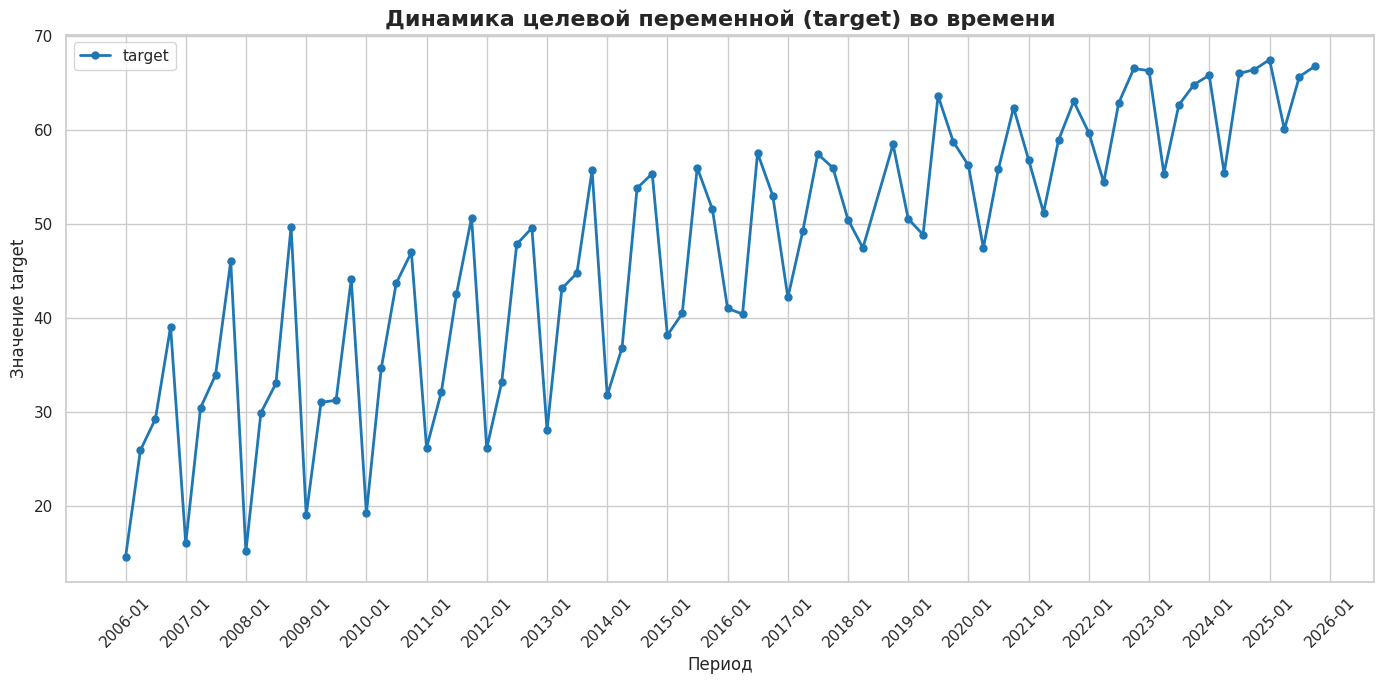

In [ ]:
import matplotlib.dates as mdates

# График измненения целевого показателя по временнм меткам
quality_indexes.index = pd.to_datetime(quality_indexes.index)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

plt.plot(quality_indexes.index, quality_indexes['target'], marker='o',
         linestyle='-', color='#1f77b4', linewidth=2,
         markersize=5, label='target')

plt.title('Динамика целевой переменной (target) во времени', fontsize=16, fontweight='bold')
plt.xlabel('Период', fontsize=12)
plt.ylabel('Значение target', fontsize=12)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1))
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()

## **Предобработка данных**

In [ ]:
# Разбиение данных
train = quality_indexes[:'2018']
val = quality_indexes['2019':'2022']
test = quality_indexes['2023':]

X_tr, y_tr = train.drop('target', axis=1), train['target']
X_val, y_val = val.drop('target', axis=1), val['target']
X_te, y_te = test.drop('target', axis=1), test['target']

In [ ]:
# Оригинальные выборки
y_tr_orig = y_tr.copy()
y_val_orig = y_val.copy()
y_te_orig = y_te.copy()

In [ ]:
# Нормализация данных
from sklearn.preprocessing import RobustScaler

# Нормализация признаков (X)
x_scaler = RobustScaler()
X_tr = pd.DataFrame(x_scaler.fit_transform(X_tr), index=X_tr.index, columns=X_tr.columns)
X_val = pd.DataFrame(x_scaler.transform(X_val), index=X_val.index, columns=X_val.columns)
X_te = pd.DataFrame(x_scaler.transform(X_te), index=X_te.index, columns=X_te.columns)

# Нормализация таргета (y)
y_scaler = RobustScaler()
y_tr = pd.Series(y_scaler.fit_transform(y_tr.values.reshape(-1, 1)).flatten(),
                 index=y_tr.index, name=y_tr.name)
y_val = pd.Series(y_scaler.transform(y_val.values.reshape(-1, 1)).flatten(),
                  index=y_val.index, name=y_val.name)
y_te = pd.Series(y_scaler.transform(y_te.values.reshape(-1, 1)).flatten(),
                 index=y_te.index, name=y_te.name)

In [ ]:
# Процентное соотношение выборок
total = len(quality_indexes)
print(f"Всего строк: {total}\n")
print(f"Train: {len(train)/total*100:.1f}%  ({len(train)} строк)")
print(f"Val:   {len(val)/total*100:.1f}%  ({len(val)} строк)")
print(f"Test:  {len(test)/total*100:.1f}%  ({len(test)} строк)")
print(f"Итоговое соотношение Train / (Val + Test): "
      f"{len(train)/total*100:.1f}% / {(len(val)+len(test))/total*100:.1f}%")

Всего строк: 79

Train: 64.6%  (51 строк)
Val:   20.3%  (16 строк)
Test:  15.2%  (12 строк)
Итоговое соотношение Train / (Val + Test): 64.6% / 35.4%


## **Обучение и оценка модели ANFIS**

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.cluster import KMeans

class ANFIS(nn.Module):
    """ANFIS модель"""
    def __init__(self, n_rules=6, n_inputs=6):
        super().__init__()
        self.n_rules = n_rules
        self.n_inputs = n_inputs
        self.centers = nn.Parameter(torch.randn(n_rules, n_inputs))
        self.sigmas = nn.Parameter(torch.ones(n_rules) * 0.5)
        self.consequents = nn.Parameter(torch.randn(n_rules, n_inputs + 1) * 0.01)

    def init_weights(self, X, y_mean):
        """Умная инициализация через KMeans."""
        if X.shape[1] != self.n_inputs:
            raise ValueError(f"Ожидалось {self.n_inputs} входов, получено {X.shape[1]}")

        kmeans = KMeans(n_clusters=self.n_rules, random_state=42, n_init=10)
        kmeans.fit(X)

        self.centers.data = torch.from_numpy(kmeans.cluster_centers_).float()

        dists = np.linalg.norm(X[:, None] - kmeans.cluster_centers_[None, :], axis=2)
        self.sigmas.data = torch.from_numpy(dists.mean(axis=0)).float().clamp(min=0.1, max=1.5)
        self.consequents.data[:, 0] = float(y_mean)

    def forward(self, x):
        x_exp = x.unsqueeze(1)
        c_exp = self.centers.unsqueeze(0)

        s_exp = self.sigmas.view(1, self.n_rules, 1)

        mu = torch.exp(-0.5 * ((x_exp - c_exp) / s_exp) ** 2)

        w = torch.prod(mu, dim=2)
        w_norm = w / w.sum(dim=1, keepdim=True).clamp(min=1e-8)

        x_bias = torch.cat([torch.ones(x.shape[0], 1, device=x.device), x], dim=1)
        rule_out = torch.einsum('bi,ri->br', x_bias, self.consequents)

        return (w_norm * rule_out).sum(dim=1, keepdim=True)


X_train_np = X_tr.values.astype(np.float32)
y_train_np = y_tr.values.astype(np.float32).flatten()
X_val_np = X_val.values.astype(np.float32)
y_val_np = y_val.values.astype(np.float32).flatten()
X_test_np = X_te.values.astype(np.float32)
y_test_np = y_te.values.astype(np.float32).flatten()

# Среднее нормализованного y для инициализации
y_train_mean = float(y_train_np.mean())

# В тензоры
X_tr_t = torch.tensor(X_train_np)
y_tr_t = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val_np)
y_val_t = torch.tensor(y_val_np, dtype=torch.float32).unsqueeze(1)
X_te_t = torch.tensor(X_test_np)

In [ ]:
# Обучение модели
N_RULES = 6
EPOCHS = 500
LR = 0.05

model = ANFIS(n_rules=N_RULES)
model.init_weights(X_train_np, y_mean=y_train_mean)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
loss_fn = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 70

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_val_t), y_val_t).item()

    train_losses.append(loss.item())
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'anfis_best.pt')
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Ранняя остановка на эпохе {epoch+1}")
        break

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f}")


Начало обучения...
Epoch 100 | Train Loss: 0.0000 | Val Loss: 0.0008
Epoch 200 | Train Loss: 0.0000 | Val Loss: 0.0000
Ранняя остановка на эпохе 234


In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# sMAPE
def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    zero_mask = (y_true == 0) & (y_pred == 0)
    denominator[zero_mask] = 1.0

    smape = np.mean(np.abs(y_pred - y_true) / denominator) * 100
    return smape


# MASE
def mean_absolute_scaled_error(y_train, y_true, y_pred, sp=1):
    y_train = np.array(y_train)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae_model = mean_absolute_error(y_true, y_pred)
    mae_naive = np.mean(np.abs(y_train[sp:] - y_train[:-sp]))

    if mae_naive == 0:
        return np.nan

    return mae_model / mae_naive


# Оценка на валидации
model.eval()
with torch.no_grad():
    y_pred_val = model(X_val_t).numpy().flatten()

mae_val = mean_absolute_error(y_val_np, y_pred_val)
rmse_val = root_mean_squared_error(y_val_np, y_pred_val)
smape_val = symmetric_mean_absolute_percentage_error(y_val_np, y_pred_val)

print(f"\nРезультаты на валидационной выборке (норм.)")
print(f"MAE: {mae_val:.4f}")
print(f"RMSE:  {rmse_val:.4f}")
print(f"sMAPE:  {smape_val:.4f}")

# Оценка на тесте
model.eval()
with torch.no_grad():
    y_pred_test = model(X_te_t).numpy().flatten()

mae_test = mean_absolute_error(y_test_np, y_pred_test)
rmse_test = root_mean_squared_error(y_test_np, y_pred_test)
smape_test = symmetric_mean_absolute_percentage_error(y_test_np, y_pred_test)

print(f"\nРезультаты на тестовой выборке (норм.)")
print(f"MAE: {mae_test:.4f}")
print(f"RMSE:  {rmse_test:.4f}")
print(f"sMAPE:  {smape_test:.4f}")


Результаты на валидационной выборке (норм.)
MAE: 0.0003
RMSE:  0.0004
sMAPE:  0.0390

Результаты на тестовой выборке (норм.)
MAE: 0.0004
RMSE:  0.0005
sMAPE:  0.0299


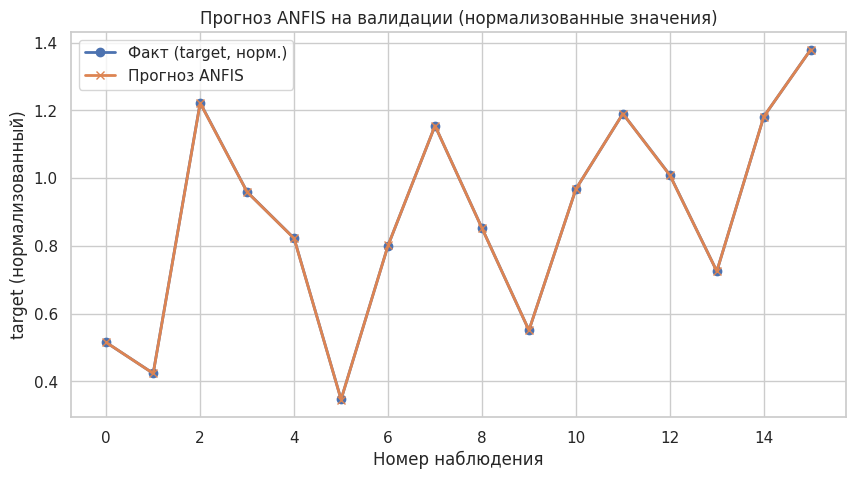

In [ ]:
# График прогноза ANFIS (VAL)
plt.figure(figsize=(10, 5))
plt.plot(y_val_np, label='Факт (target, норм.)', marker='o', linewidth=2)
plt.plot(y_pred_val, label='Прогноз ANFIS', marker='x', linewidth=2)
plt.title('Прогноз ANFIS на валидации (нормализованные значения)')
plt.xlabel('Номер наблюдения')
plt.ylabel('target (нормализованный)')
plt.legend()
plt.grid(True)

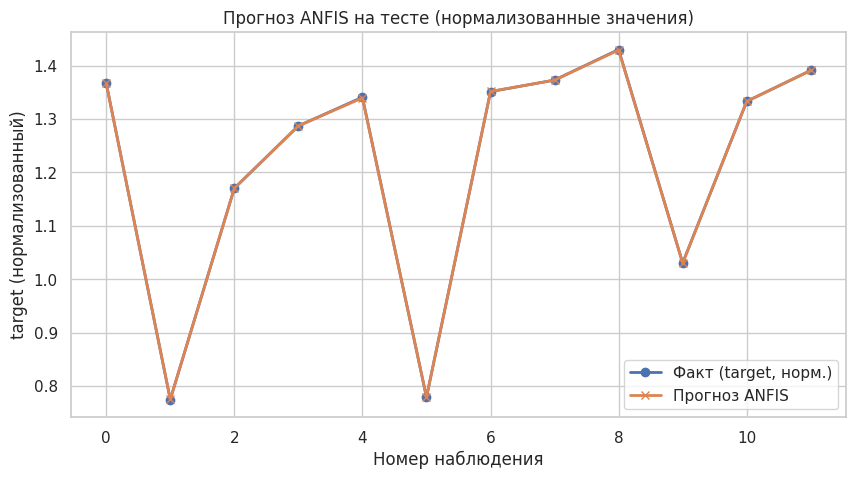

In [ ]:
# График прогноза ANFIS (TEST)
plt.figure(figsize=(10, 5))
plt.plot(y_test_np, label='Факт (target, норм.)', marker='o', linewidth=2)
plt.plot(y_pred_test, label='Прогноз ANFIS', marker='x', linewidth=2)
plt.title('Прогноз ANFIS на тесте (нормализованные значения)')
plt.xlabel('Номер наблюдения')
plt.ylabel('target (нормализованный)')
plt.legend()
plt.grid(True)

## **Сравнение модели ANFIS с Baseline-1,2**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_all_metrics(y_train, y_true, y_pred, sp=1):
    """Рассчитывает 4 метрики: MAE, MSE, sMAPE, MASE"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    smape = symmetric_mean_absolute_percentage_error(y_true, y_pred)
    mase = mean_absolute_scaled_error(y_train, y_true, y_pred, sp)

    return {
        'MAE': mae,
        'MSE': mse,
        'sMAPE': smape,
        'MASE': mase
    }

In [ ]:
# Метрики ANFIS
model.eval()
with torch.no_grad():
    y_pred_anfis = model(X_te_t).numpy().flatten()

metrics_anfis = calculate_all_metrics(y_train_np, y_test_np, y_pred_anfis)

In [ ]:
# Baseline 1 - Seasonal Naive | Метрики
y_history = np.concatenate([y_train_np, y_val_np])
y_pred_sn = []
for i in range(len(y_test_np)):
    idx_in_history = len(y_history) - 4 + i

    if idx_in_history >= 0 and idx_in_history < len(y_history):
        y_pred_sn.append(y_history[idx_in_history])
    else:
        idx_in_pred = idx_in_history - len(y_history)
        y_pred_sn.append(y_pred_sn[idx_in_pred])

y_pred_sn = np.array(y_pred_sn)
metrics_sn = calculate_all_metrics(y_train_np, y_test_np, y_pred_sn, sp=4)

In [ ]:
# Baseline 2 - Ridge Regression на лаговых признаках | Метрики
from sklearn.linear_model import Ridge

def create_lag_features(y, n_lags=4):
    """Создает лаговые признаки и скользящее среднее"""
    n = len(y)
    features = []

    for lag in [1, 2, 4]:
        lagged = np.full(n, np.nan)
        lagged[lag:] = y[:-lag]
        features.append(lagged)

    ma4 = np.full(n, np.nan)
    for i in range(4, n):
        ma4[i] = np.mean(y[i-4:i])
    features.append(ma4)

    return np.column_stack(features)


y_full = np.concatenate([y_train_np, y_val_np, y_test_np])
lags_full = create_lag_features(y_full, n_lags=4)

lags_train = lags_full[:len(y_train_np)]
lags_test = lags_full[len(y_train_np)+len(y_val_np):]

valid_mask_train = ~np.isnan(lags_train).any(axis=1)
lags_train_clean = lags_train[valid_mask_train]
y_train_clean = y_train_np[valid_mask_train]

valid_mask_test = ~np.isnan(lags_test).any(axis=1)
lags_test_clean = lags_test[valid_mask_test]
y_test_clean = y_test_np[valid_mask_test]

ridge = Ridge(alpha=1.0)
ridge.fit(lags_train_clean, y_train_clean)
y_pred_ridge = ridge.predict(lags_test_clean)

metrics_ridge = calculate_all_metrics(y_train_clean, y_test_clean, y_pred_ridge)

In [ ]:
# Сравнение метрик
comparison_df = pd.DataFrame({
    'Seasonal Naive': metrics_sn,
    'Ridge Regression': metrics_ridge,
    'ANFIS': metrics_anfis
}).T

final_table = comparison_df.copy()
final_table['MAE'] = final_table['MAE'].apply(lambda x: f"{x:.4f}")
final_table['MSE'] = final_table['MSE'].apply(lambda x: f"{x:.4f}")
final_table['sMAPE'] = final_table['sMAPE'].apply(lambda x: f"{x:.2f}%")
final_table['MASE'] = final_table['MASE'].apply(lambda x: f"{x:.4f}")

print(final_table.to_string())

                     MAE     MSE   sMAPE    MASE
Seasonal Naive    0.1634  0.0478  14.66%  0.8698
Ridge Regression  0.0954  0.0143   8.34%  0.1581
ANFIS             0.0004  0.0000   0.03%  0.0006


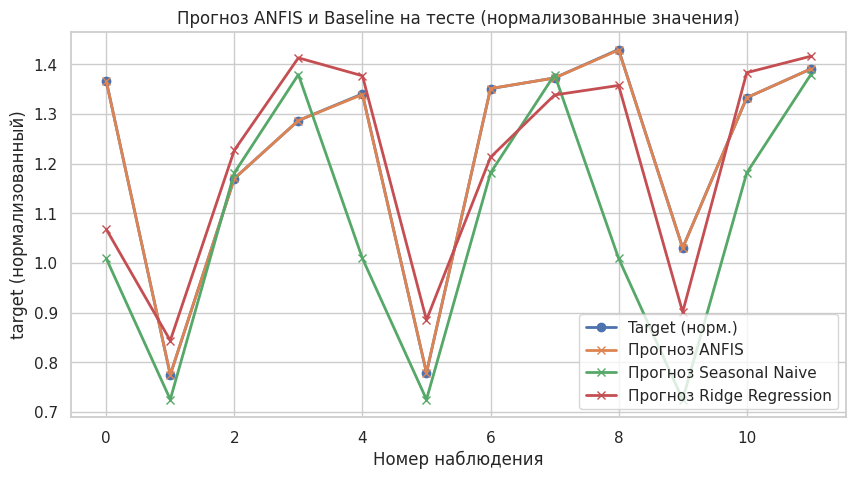

In [ ]:
# График прогноза 4-х моделей
plt.figure(figsize=(10, 5))
plt.title('Прогноз ANFIS и Baseline на тесте (нормализованные значения)')
plt.plot(y_test_np, label='Target (норм.)', marker='o', linewidth=2)
plt.plot(y_pred_test, label='Прогноз ANFIS', marker='x', linewidth=2)
plt.plot(y_pred_sn, label='Прогноз Seasonal Naive', marker='x', linewidth=2)
plt.plot(y_pred_ridge, label='Прогноз Ridge Regression', marker='x', linewidth=2)
plt.xlabel('Номер наблюдения')
plt.ylabel('target (нормализованный)')
plt.legend()
plt.grid(True)

## **Загрузка модели ANFIS**

In [ ]:
# Скейлеры
import joblib

joblib.dump(x_scaler, 'x_scaler.pkl')
joblib.dump(y_scaler, 'y_scaler.pkl')

['y_scaler.pkl']

In [ ]:
# Загрузка модели
x_scaler = joblib.load('x_scaler.pkl')
y_scaler = joblib.load('y_scaler.pkl')

n_inputs = x_scaler.scale_.shape[0]

ANFIS_model = ANFIS(n_rules=6, n_inputs=n_inputs)

ANFIS_model.load_state_dict(torch.load('anfis_best.pt', map_location='cpu'))
ANFIS_model.eval()

print("Модель успешно загружена!")

Модель успешно загружена!


In [ ]:
# Предикт на новых данных
def predict_new_data(raw_data):
    if isinstance(raw_data, pd.DataFrame):
        raw_data = raw_data.values

    X_scaled = x_scaler.transform(raw_data.astype(np.float32))
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

    with torch.no_grad():
        y_pred_scaled = ANFIS_model(X_tensor).cpu().numpy().flatten()

    y_pred_real = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    return y_pred_real